# Modèle de Probabilité de Défaut (PD) 
## Analyse Exploratoire des Données (EDA)
---
**Objectif :** Comprendre la structure des données, identifier les variables clés, détecter les anomalies et préparer la base pour la modélisation.


## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Chemins
DATA_PATH = r'C:\Users\nadhm\OneDrive\Desktop\Personal Documents\Stage EY\Projet Dhirar\PD_Model\data\simulated_retail_pd_dataset_10_variables.xlsx'

print('✅ Imports OK')


✅ Imports OK


## 1. Chargement des données

In [2]:
df = pd.read_excel(DATA_PATH)

print(f"Dimensions        : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Variables         : {list(df.columns)}")
print("\nAperçu :")
df.head()


Dimensions        : 12,000 lignes × 12 colonnes
Variables         : ['customer_id', 'default_12m', 'bureau_score', 'dti', 'utilization_rate', 'max_dpd_12m', 'missed_payments_3m', 'overdrawn_days_3m', 'number_of_credit_inquiries_6m', 'employment_status', 'monthly_income', 'salary_domiciliation']

Aperçu :


,customer_id,default_12m,bureau_score,dti,utilization_rate,max_dpd_12m,missed_payments_3m,overdrawn_days_3m,number_of_credit_inquiries_6m,employment_status,monthly_income,salary_domiciliation
0,CUST_000026,0,696.0,0.106,0.341,0,0,4,1,Self-employed,2490.0,1
1,CUST_000095,0,684.0,0.725,0.551,0,0,4,0,Retired,584.0,0
2,CUST_000099,0,775.0,0.079,0.583,0,0,0,0,Permanent,1930.0,1
3,CUST_000109,0,755.0,0.395,0.800,60,2,11,2,Permanent,1880.0,0
4,CUST_000119,0,601.0,0.342,0.419,0,0,5,2,Self-employed,1277.0,0


In [3]:
# Types de données
print("Types de variables :")
print(df.dtypes)


Types de variables :
customer_id                       object
default_12m                        int64
bureau_score                     float64
dti                              float64
utilization_rate                 float64
max_dpd_12m                        int64
missed_payments_3m                 int64
overdrawn_days_3m                  int64
number_of_credit_inquiries_6m      int64
employment_status                 object
monthly_income                   float64
salary_domiciliation               int64
dtype: object


### 💡 Interprétation : Chargement des données
* **Volume** : Le dataset comporte **12 000 observations (clients)**, ce qui est statistiquement robuste pour l'entraînement d'un modèle stable de Score de Crédit.
* **Variables** : Nous avons un identifiant client (`customer_id`), une variable cible binaire (`default_12m`), et 10 variables explicatives (prédicteurs de risque).
* **Types** : Les variables sont correctement typées (numériques réelles pour les taux et scores, entières pour les jours de retard et comptes, et catégorielles pour les situations d'emploi).


## 2. Variable Cible — `default_12m`
On commence toujours par analyser la cible : son taux et son équilibre.


Non-défaut (0) : 10,396  (86.63%)
Défaut     (1) : 1,604  (13.37%)

⚠️  Déséquilibre des classes : ratio 1:6


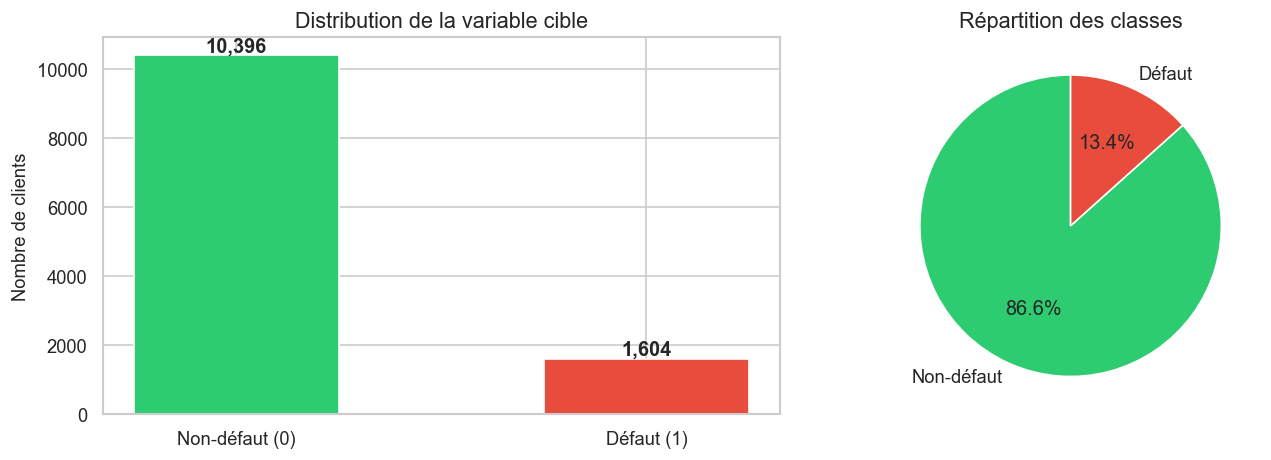

In [4]:
counts = df['default_12m'].value_counts()
taux   = df['default_12m'].mean() * 100

print(f"Non-défaut (0) : {counts[0]:,}  ({100-taux:.2f}%)")
print(f"Défaut     (1) : {counts[1]:,}  ({taux:.2f}%)")
print(f"\n⚠️  Déséquilibre des classes : ratio 1:{counts[0]//counts[1]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
axes[0].bar(['Non-défaut (0)', 'Défaut (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Distribution de la variable cible')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['Non-défaut', 'Défaut'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Répartition des classes')

plt.tight_layout()
plt.savefig('../reports/figures/01_target_distribution.png', bbox_inches='tight')
plt.show()


### 💡 Interprétation : Analyse de la Variable Cible
* **Taux de défaut** : **13,37 %** des clients (1 604) ont fait défaut, tandis que **86,63 %** (10 396) sont sains.
* **Déséquilibre des classes** : Il existe un déséquilibre de **1:6,5**. Ce niveau est idéal car il fournit assez d'exemples de défaut au modèle sans nécessiter de techniques complexes de rééchantillonnage artificiel (ex. SMOTE).
* **Conseil d'évaluation** : Les métriques comme l'**AUC-ROC**, le **Rappel** (pour capter le maximum de défauts) et le **score F1** devront être privilégiées par rapport à l'exactitude globale (accuracy).


## 3. Valeurs Manquantes
Identification et visualisation des données manquantes.


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
}).query('`Valeurs manquantes` > 0')

print("Variables avec valeurs manquantes :")
print(missing_df.to_string())


Variables avec valeurs manquantes :
                Valeurs manquantes  Pourcentage (%)
bureau_score                   298             2.48
monthly_income                 431             3.59


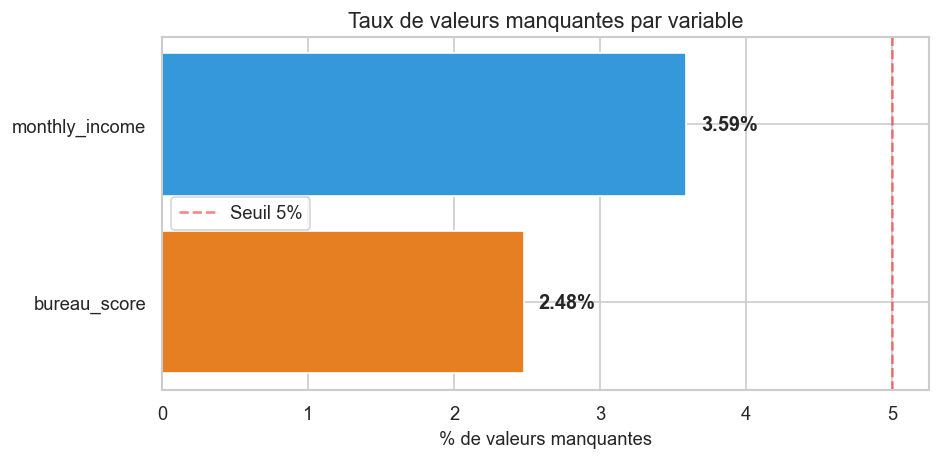

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

vars_missing = missing_df.index.tolist()
pcts = missing_df['Pourcentage (%)'].values

bars = ax.barh(vars_missing, pcts, color=['#e67e22', '#3498db'], edgecolor='white')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par variable')
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='Seuil 5%')
ax.legend()

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/02_missing_values.png', bbox_inches='tight')
plt.show()


In [7]:
# Analyse : les clients avec bureau_score manquant défautent-ils plus ?
print("Taux de défaut selon disponibilité de bureau_score :")
df['bureau_score_missing'] = df['bureau_score'].isnull().astype(int)
print(df.groupby('bureau_score_missing')['default_12m'].mean().rename({0:'Renseigné', 1:'Manquant'}).apply(lambda x: f'{x*100:.2f}%'))

print("\nTaux de défaut selon disponibilité de monthly_income :")
df['monthly_income_missing'] = df['monthly_income'].isnull().astype(int)
print(df.groupby('monthly_income_missing')['default_12m'].mean().rename({0:'Renseigné', 1:'Manquant'}).apply(lambda x: f'{x*100:.2f}%'))

# Nettoyage colonnes helper
df.drop(columns=['bureau_score_missing','monthly_income_missing'], inplace=True)


Taux de défaut selon disponibilité de bureau_score :
bureau_score_missing
Renseigné    13.35%
Manquant     14.09%
Name: default_12m, dtype: object

Taux de défaut selon disponibilité de monthly_income :
monthly_income_missing
Renseigné    13.42%
Manquant     11.83%
Name: default_12m, dtype: object


### 💡 Interprétation : Valeurs Manquantes
* **Variables concernées** : Seules **`bureau_score`** (2,48% de valeurs manquantes soit 298 valeurs) et **`monthly_income`** (3,59% de valeurs manquantes soit 431 valeurs) ont des données manquantes.
* **Lien avec le risque** : Le taux de défaut des clients ayant des données manquantes est quasiment identique à celui des clients renseignés (ex. 13,35% contre 14,09% pour le score bureau).
* **Action** : L'absence de donnée n'est pas informative en soi (mécanisme de type MCAR/MAR). Nous imputerons ces valeurs par la **médiane** de chaque variable lors de la phase de prétraitement (`preprocessing.py`).


## 4. Statistiques Descriptives
Vue d'ensemble des variables numériques.


In [8]:
num_cols = ['bureau_score','dti','utilization_rate','max_dpd_12m',
            'missed_payments_3m','overdrawn_days_3m',
            'number_of_credit_inquiries_6m','monthly_income']

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew().round(3)
desc['kurtosis'] = df[num_cols].kurt().round(3)
desc.round(2)


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
bureau_score,11702.0,650.31,87.95,300.00,592.00,652.00,710.00,850.00,-0.11,-0.15
dti,12000.0,0.41,0.21,0.02,0.25,0.39,0.55,1.35,0.57,0.10
utilization_rate,12000.0,0.47,0.23,0.01,0.30,0.45,0.63,1.25,0.37,-0.34
max_dpd_12m,12000.0,13.40,22.66,0.00,0.00,0.00,15.00,90.00,1.91,2.98
missed_payments_3m,12000.0,0.33,0.66,0.00,0.00,0.00,0.00,7.00,2.50,8.08
overdrawn_days_3m,12000.0,3.36,2.90,0.00,1.00,2.50,5.00,15.00,0.87,0.05
number_of_credit_inquiries_6m,12000.0,1.10,1.17,0.00,0.00,1.00,2.00,10.00,1.33,2.48
monthly_income,11569.0,2229.28,1302.38,350.00,1400.00,1975.00,2754.00,15000.00,2.39,11.50


### 💡 Interprétation : Statistiques Descriptives
* **Variables de comportement** : `max_dpd_12m` a une moyenne de 13,4 jours et une médiane de 0, indiquant que la majorité des clients n'ont pas de retard de paiement récent, mais qu'une sous-population présente de forts incidents (max à 90 jours).
* **Asymétrie extrême** : `monthly_income` présente un skewness très prononcé (2,39) et un kurtosis élevé (11,50). La médiane est à 1 975 alors que le revenu maximal grimpe à 15 000.
* **Action** : Un plafonnement (capping) ou une transformation logarithmique sera nécessaire pour éviter que ces revenus géants atypiques ne faussent l'apprentissage du modèle de régression.


## 5. Distribution des Variables Numériques
Histogrammes avec séparation défaut / non-défaut pour détecter le pouvoir discriminant.


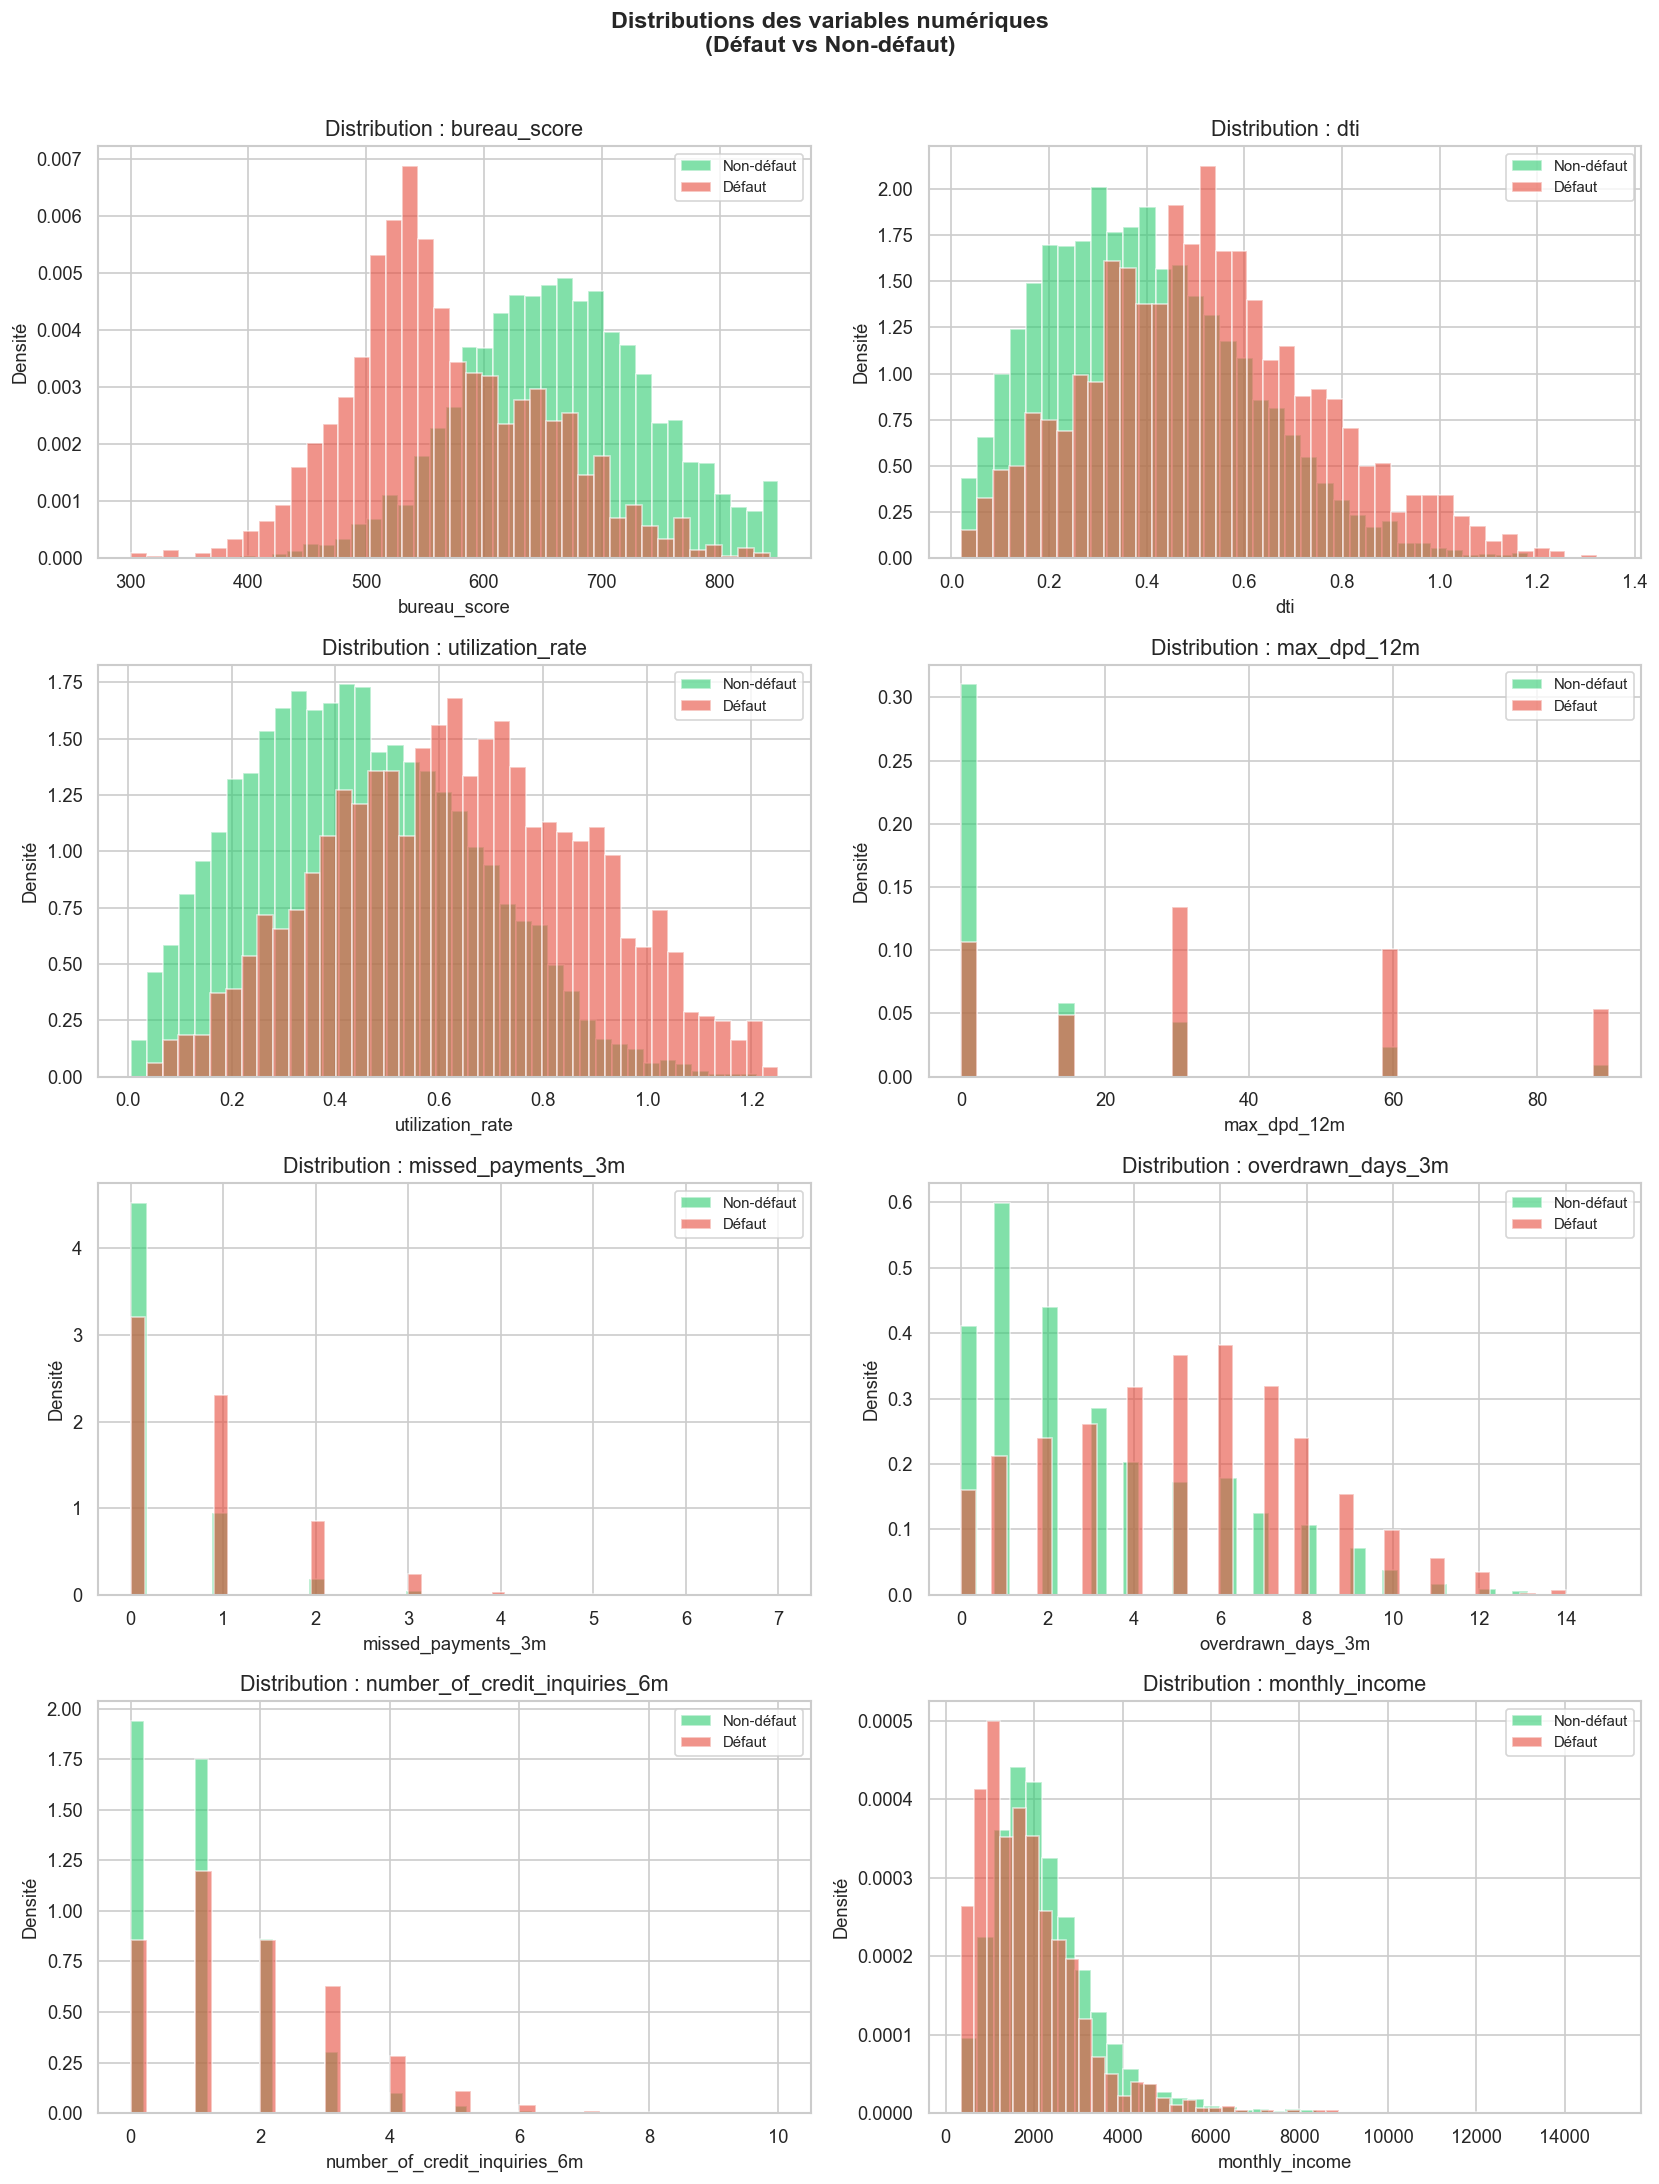

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

colors = {0: '#2ecc71', 1: '#e74c3c'}
labels = {0: 'Non-défaut', 1: 'Défaut'}

for i, col in enumerate(num_cols):
    ax = axes[i]
    for target in [0, 1]:
        subset = df[df['default_12m'] == target][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=colors[target],
                label=labels[target], edgecolor='white', density=True)
    ax.set_title(f'Distribution : {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)

plt.suptitle('Distributions des variables numériques\n(Défaut vs Non-défaut)', 
             y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_distributions.png', bbox_inches='tight')
plt.show()


### 💡 Interprétation : Visualisation des Distributions (Défaut vs Non-défaut)
* **Séparabilité visuelle** : Le graphique montre clairement que le **`bureau_score`** a un excellent pouvoir discriminant. Les clients sains se concentrent à droite (hauts scores), tandis que les clients en défaut s'entassent à gauche (bas scores).
* **Tensions financières** : Les histogrammes de `utilization_rate` et `dti` montrent que les clients en défaut ont des distributions décalées vers le haut, confirmant que le surendettement et l'utilisation intensive des lignes de crédit sont corrélés avec le défaut.


## 6. Détection des Outliers — Boxplots


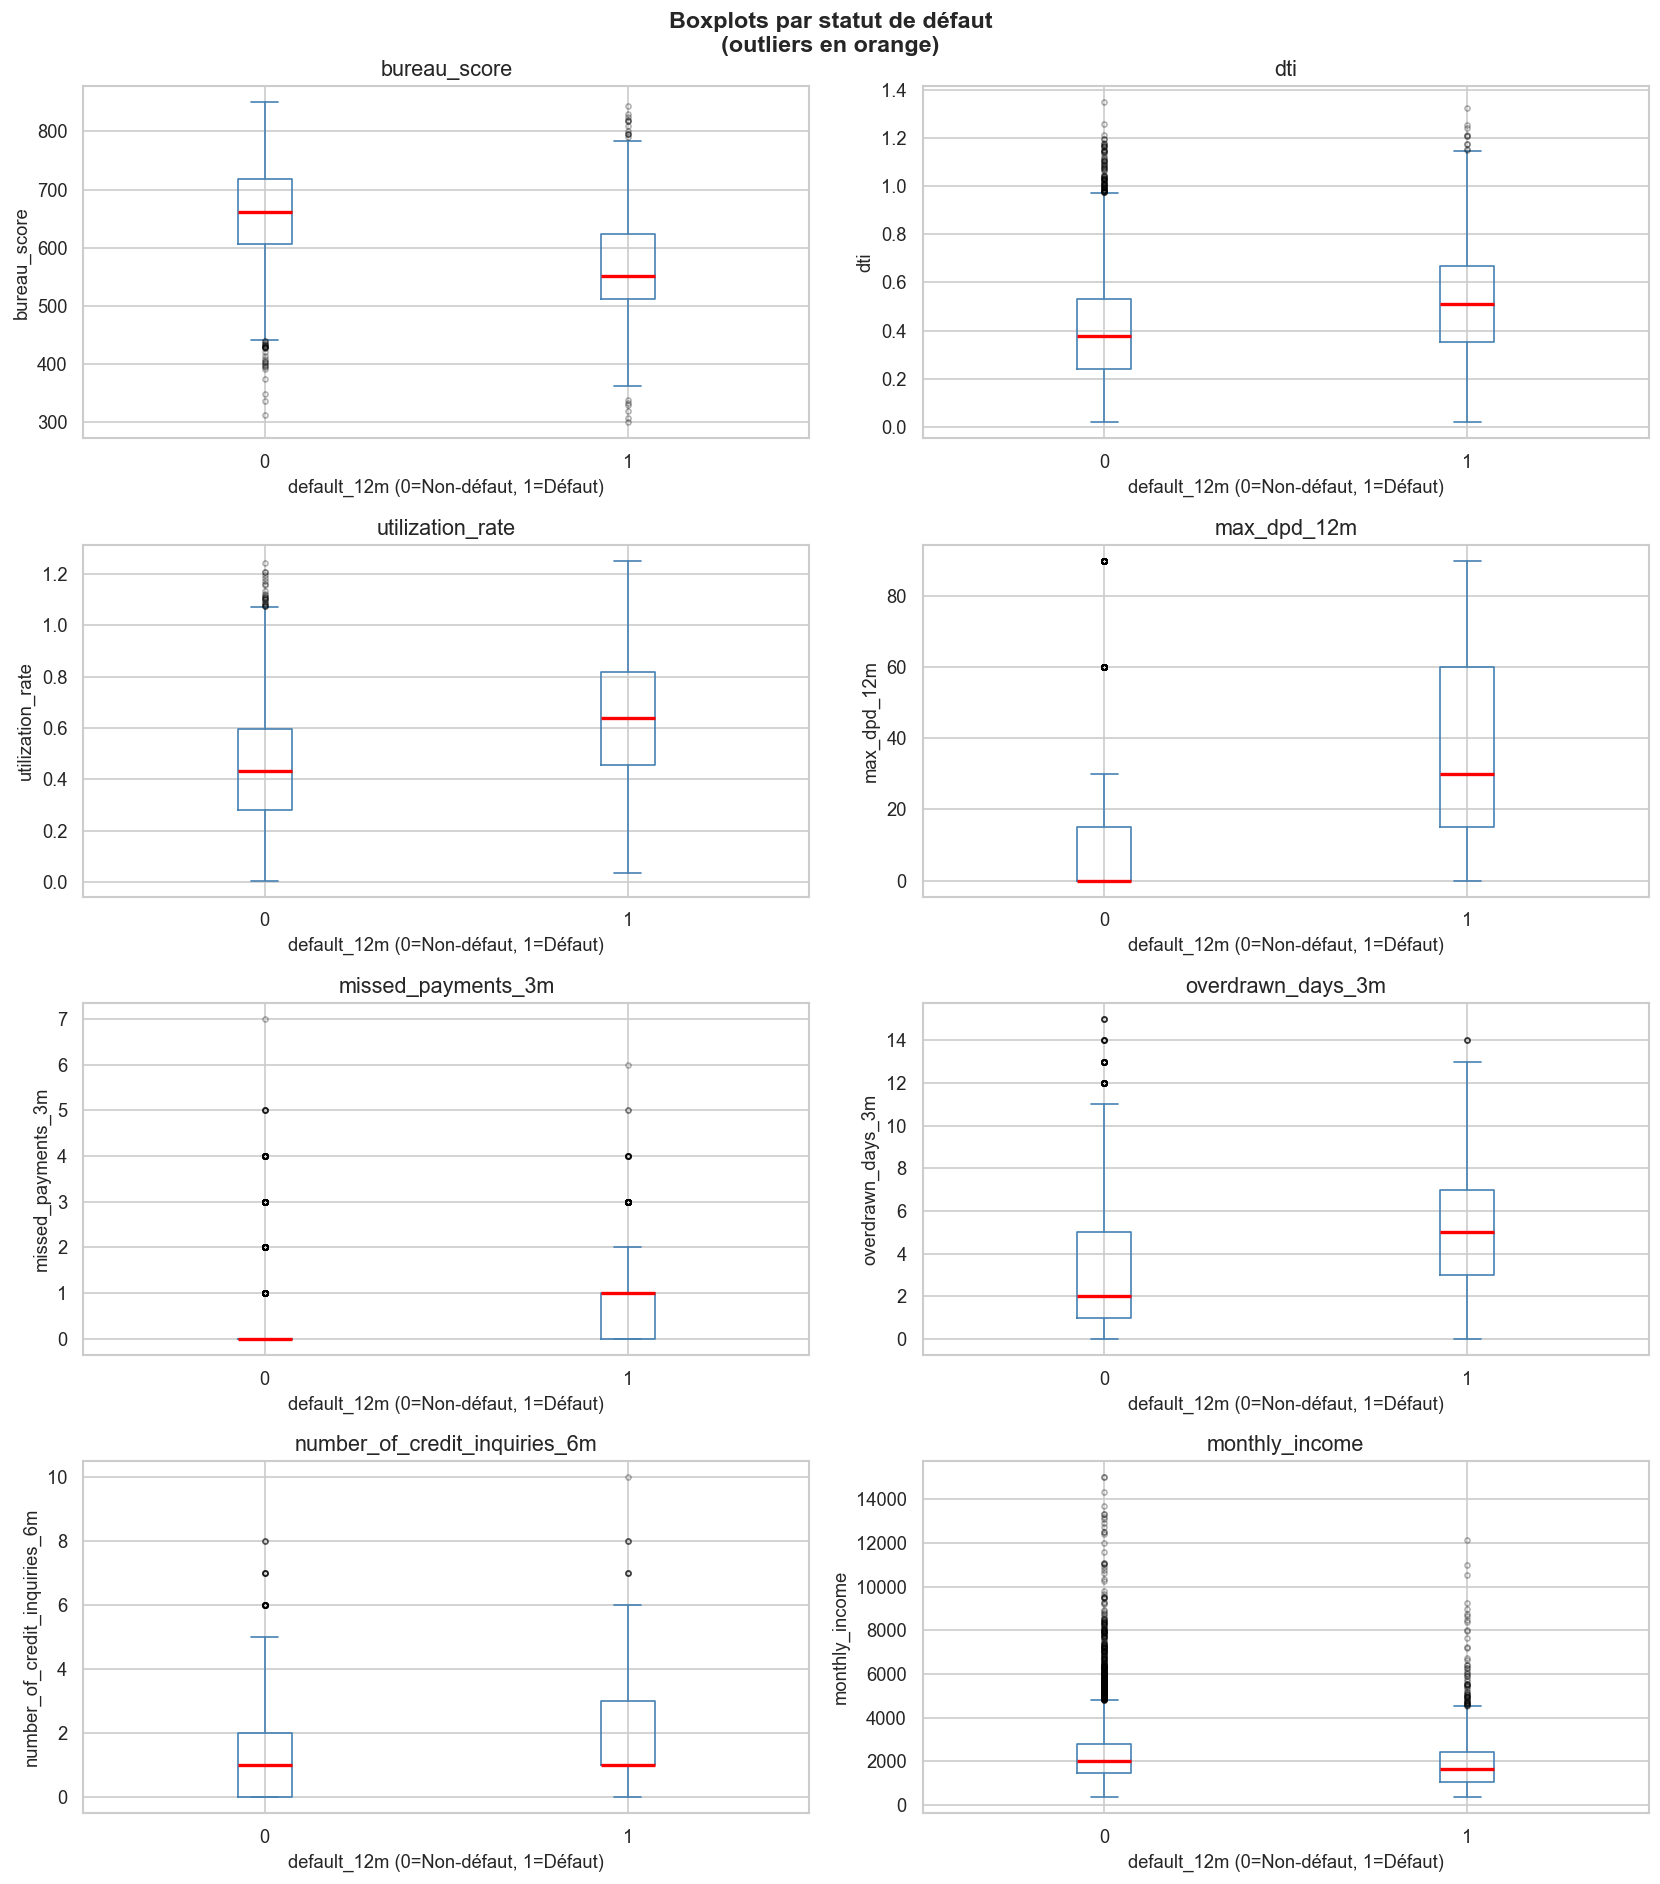


📌 Synthèse des outliers potentiels (valeurs > Q3 + 3*IQR) :
  max_dpd_12m                              : 415 outliers extrêmes
  missed_payments_3m                       : 2992 outliers extrêmes
  number_of_credit_inquiries_6m            : 1 outliers extrêmes
  monthly_income                           : 130 outliers extrêmes


In [10]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='default_12m', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'),
               flierprops=dict(marker='o', color='orange', alpha=0.3, markersize=3))
    ax.set_title(col)
    ax.set_xlabel('default_12m (0=Non-défaut, 1=Défaut)')
    ax.set_ylabel(col)

plt.suptitle('Boxplots par statut de défaut\n(outliers en orange)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_boxplots.png', bbox_inches='tight')
plt.show()

# Synthèse outliers
print("\n📌 Synthèse des outliers potentiels (valeurs > Q3 + 3*IQR) :")
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = (df[col] > q3 + 3*iqr).sum()
    if n_out > 0:
        print(f"  {col:40s} : {n_out} outliers extrêmes")


### 💡 Interprétation : Détection des Outliers
* **Valeurs aberrantes** : De nombreuses observations (points orange) se situent bien au-delà de la moustache supérieure (Q3 + 3*IQR), en particulier sur `monthly_income` (130 outliers) et `missed_payments_3m` (2 992 outliers dus à la nature discrète de la variable).
* **Action** : Le modèle de régression logistique étant sensible aux points extrêmes, nous appliquerons un **capping au 99ème centile** sur les variables continues fortement étirées.


## 7. Variable Catégorielle — `employment_status`
Analyse du taux de défaut par statut d'emploi.


                   nb_clients  taux_defaut  taux_defaut_pct
employment_status                                          
Unemployed                831     0.369434            36.94
Temporary                1835     0.186376            18.64
Retired                   602     0.146179            14.62
Self-employed            2109     0.109056            10.91
Permanent                6623     0.096180             9.62


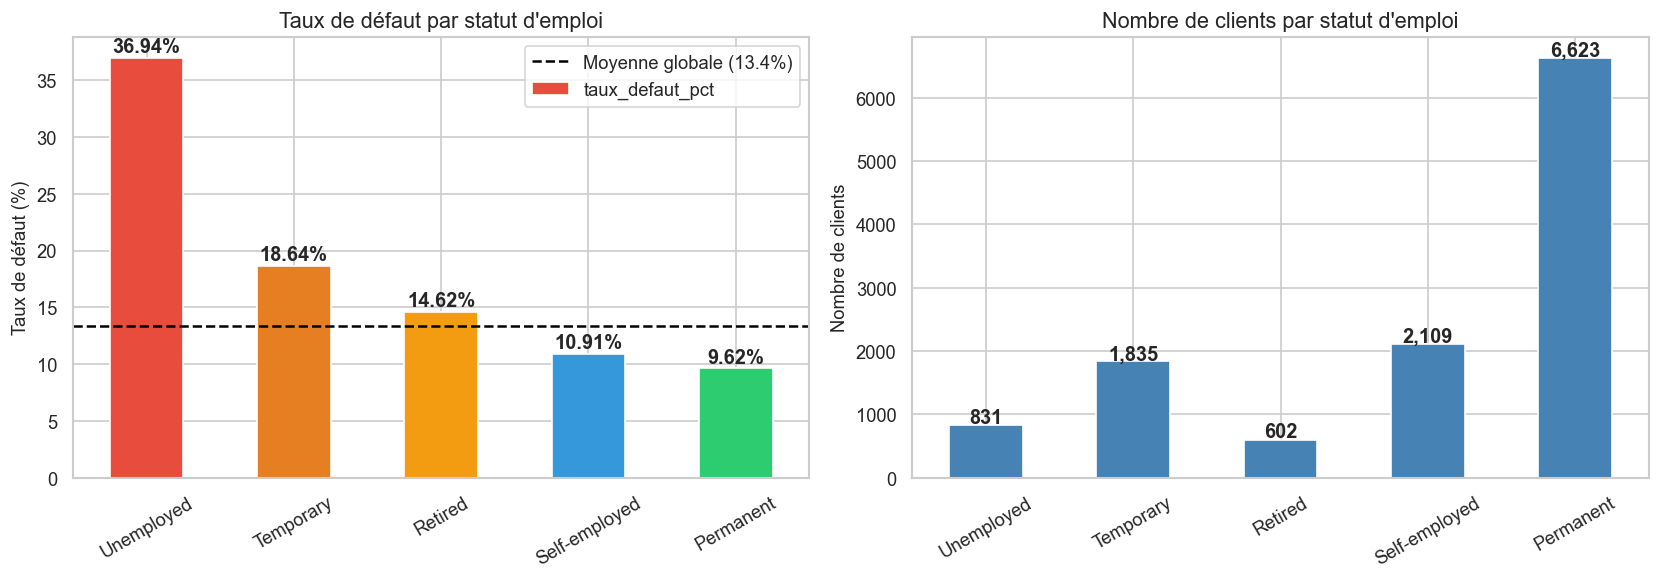

In [11]:
emp_default = df.groupby('employment_status').agg(
    nb_clients=('default_12m', 'count'),
    taux_defaut=('default_12m', 'mean')
).sort_values('taux_defaut', ascending=False)

emp_default['taux_defaut_pct'] = (emp_default['taux_defaut'] * 100).round(2)
print(emp_default.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de défaut
emp_default['taux_defaut_pct'].plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#e67e22','#f39c12','#3498db','#2ecc71'],
    edgecolor='white')
axes[0].set_title("Taux de défaut par statut d'emploi")
axes[0].set_ylabel("Taux de défaut (%)")
axes[0].set_xlabel("")
axes[0].axhline(df['default_12m'].mean()*100, color='black',
                linestyle='--', label=f'Moyenne globale ({df["default_12m"].mean()*100:.1f}%)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(emp_default['taux_defaut_pct']):
    axes[0].text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')

# Volume
emp_default['nb_clients'].plot(kind='bar', ax=axes[1],
    color='steelblue', edgecolor='white')
axes[1].set_title("Nombre de clients par statut d'emploi")
axes[1].set_ylabel("Nombre de clients")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(emp_default['nb_clients']):
    axes[1].text(i, v+30, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/05_employment_status.png', bbox_inches='tight')
plt.show()


### 💡 Interprétation : Impact de la Situation Professionnelle
* **Inégalité de risque** : Le taux de défaut est de **36,94 %** pour les sans-emploi (`Unemployed`) et de **18,64 %** pour les contrats temporaires (`Temporary`), contre seulement **9,62 %** pour les salariés stables en CDI (`Permanent`).
* **Prédicteur clé** : Le statut professionnel est l'un des meilleurs indicateurs qualitatifs du risque de défaut. Un encodage de type **One-Hot Encoding** est indispensable pour que le modèle puisse exploiter ces catégories.


## 8. Matrice de Corrélation
Identification des relations entre variables et avec la cible.


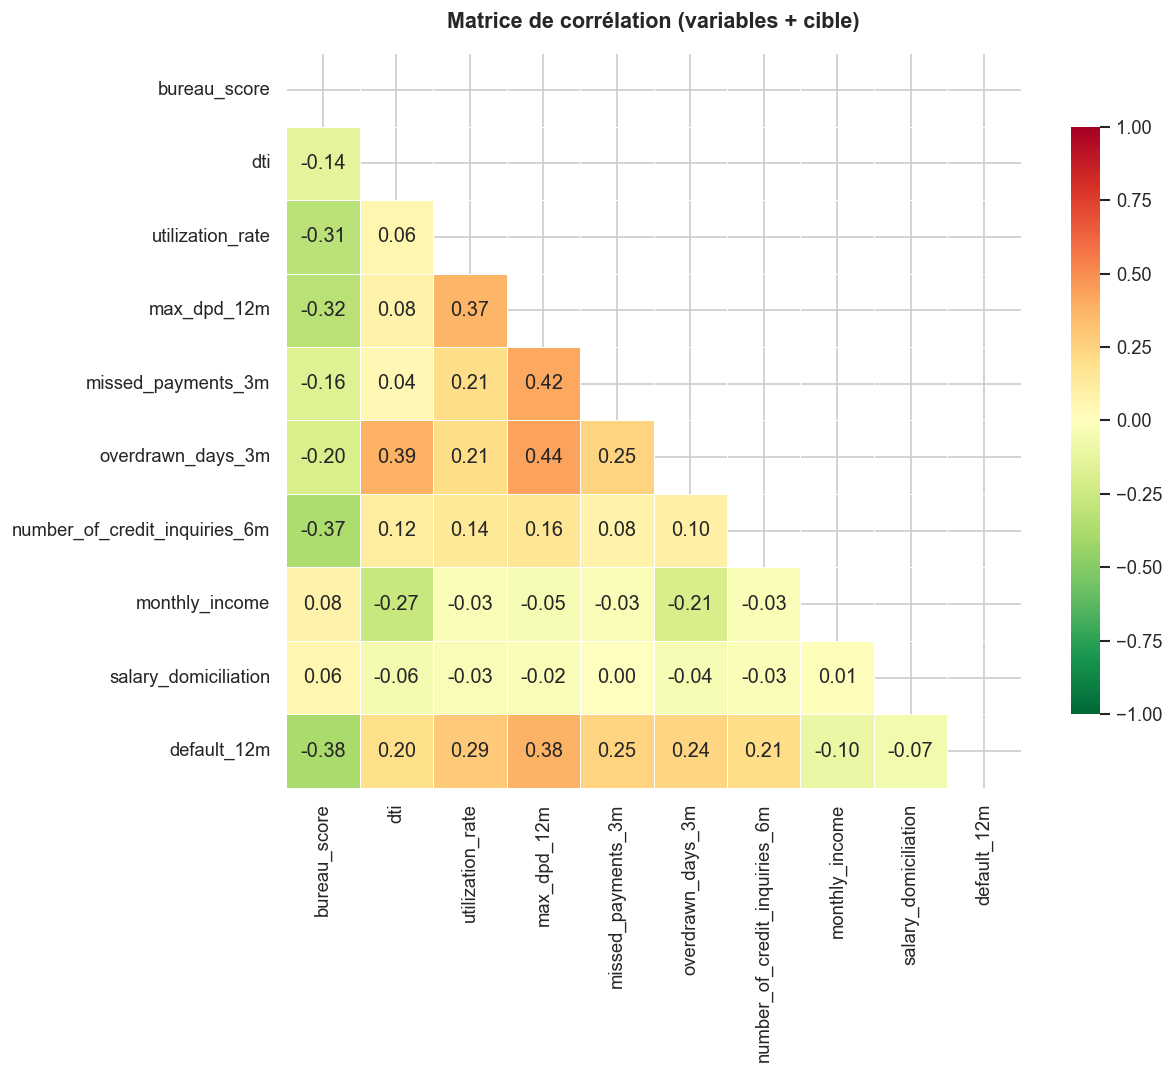

In [12]:
corr_cols = num_cols + ['salary_domiciliation', 'default_12m']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Matrice de corrélation (variables + cible)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/figures/06_correlation_matrix.png', bbox_inches='tight')
plt.show()


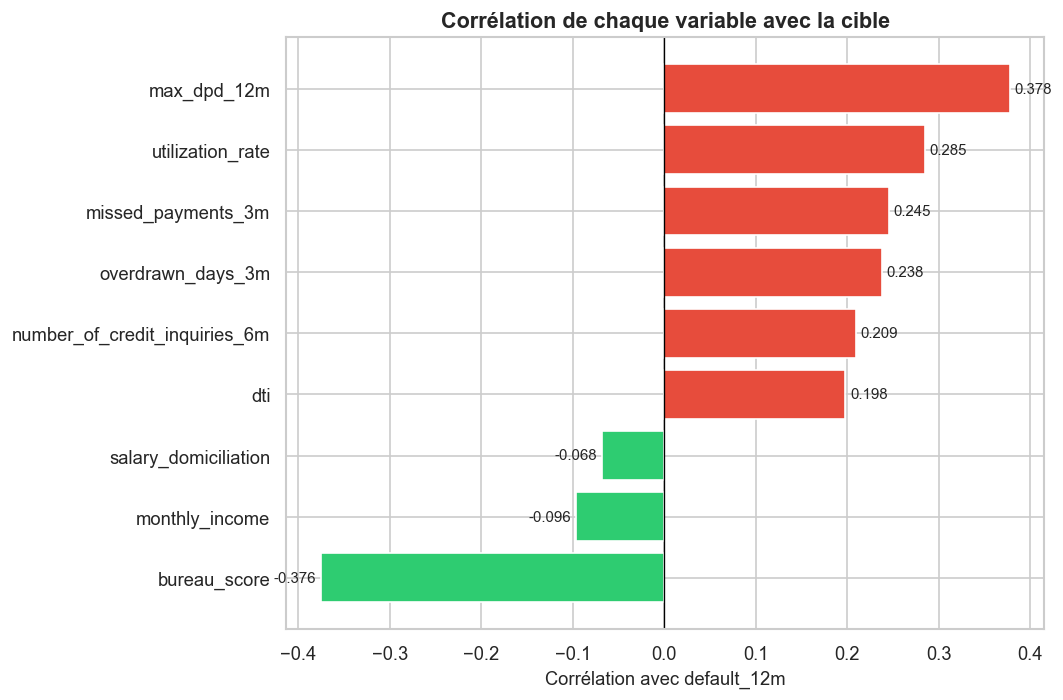


📌 Interprétation :
  Variables protectrices  (corrélation négative) : bureau_score, monthly_income, salary_domiciliation
  Variables de risque     (corrélation positive)  : max_dpd_12m, utilization_rate, missed_payments_3m


In [13]:
# Corrélation avec la cible uniquement
corr_target = df[corr_cols].corr()['default_12m'].drop('default_12m').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Corrélation avec default_12m')
ax.set_title('Corrélation de chaque variable avec la cible', fontweight='bold')

for bar, v in zip(bars, corr_target.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), 
            bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/07_correlation_target.png', bbox_inches='tight')
plt.show()

print("\n📌 Interprétation :")
print("  Variables protectrices  (corrélation négative) : bureau_score, monthly_income, salary_domiciliation")
print("  Variables de risque     (corrélation positive)  : max_dpd_12m, utilization_rate, missed_payments_3m")


### 💡 Interprétation : Corrélations et Multicolinéarité
* **Absence de redondance** : La corrélation explicative maximale entre variables prédictives est de ~0,37. Il n'y a aucun risque de **multicolinéarité**, ce qui signifie que toutes les variables explicatives peuvent être conservées sans déstabiliser les coefficients du modèle.
* **Forces des signaux** : Le `bureau_score` (-0,38) et `max_dpd_12m` (+0,38) sont les variables les plus fortement liées au défaut de paiement (l'une négativement et l'autre positivement).


## 9. Analyse Bivariée — Taux de défaut par bucket
Découpage des variables continues en tranches pour visualiser la relation avec le défaut.


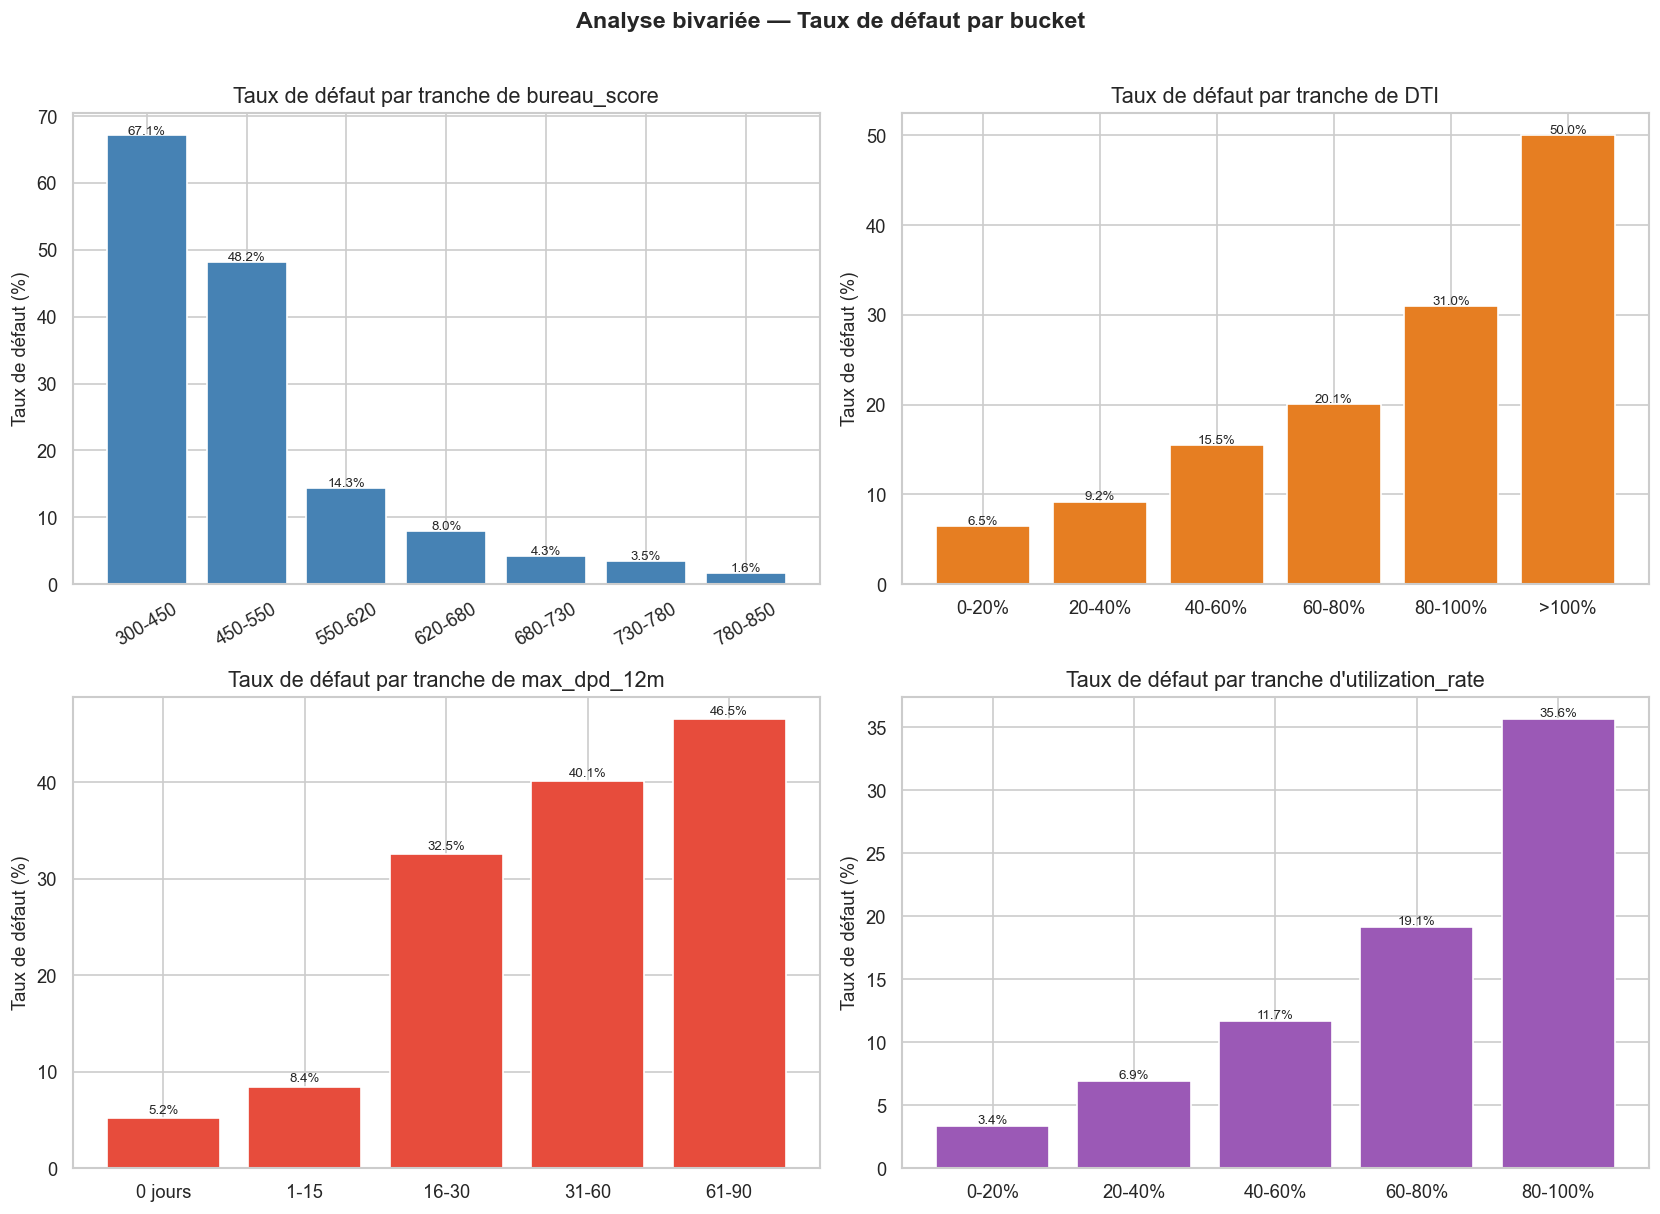

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# bureau_score
df['score_bucket'] = pd.cut(df['bureau_score'], bins=[300,450,550,620,680,730,780,850],
                             labels=['300-450','450-550','550-620','620-680','680-730','730-780','780-850'])
rate = df.groupby('score_bucket', observed=True)['default_12m'].mean() * 100
axes[0,0].bar(rate.index.astype(str), rate.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Taux de défaut par tranche de bureau_score')
axes[0,0].set_ylabel('Taux de défaut (%)')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(rate.values):
    axes[0,0].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=8)

# dti
df['dti_bucket'] = pd.cut(df['dti'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0, 10],
                           labels=['0-20%','20-40%','40-60%','60-80%','80-100%','>100%'])
rate2 = df.groupby('dti_bucket', observed=True)['default_12m'].mean() * 100
axes[0,1].bar(rate2.index.astype(str), rate2.values, color='#e67e22', edgecolor='white')
axes[0,1].set_title('Taux de défaut par tranche de DTI')
axes[0,1].set_ylabel('Taux de défaut (%)')
for i, v in enumerate(rate2.values):
    axes[0,1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=8)

# max_dpd_12m
df['dpd_bucket'] = pd.cut(df['max_dpd_12m'], bins=[-1, 0, 15, 30, 60, 90, 1000],
                           labels=['0 jours','1-15','16-30','31-60','61-90','>90'])
rate3 = df.groupby('dpd_bucket', observed=True)['default_12m'].mean() * 100
axes[1,0].bar(rate3.index.astype(str), rate3.values, color='#e74c3c', edgecolor='white')
axes[1,0].set_title('Taux de défaut par tranche de max_dpd_12m')
axes[1,0].set_ylabel('Taux de défaut (%)')
for i, v in enumerate(rate3.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=8)

# utilization_rate
df['util_bucket'] = pd.cut(df['utilization_rate'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                            labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])
rate4 = df.groupby('util_bucket', observed=True)['default_12m'].mean() * 100
axes[1,1].bar(rate4.index.astype(str), rate4.values, color='#9b59b6', edgecolor='white')
axes[1,1].set_title("Taux de défaut par tranche d'utilization_rate")
axes[1,1].set_ylabel('Taux de défaut (%)')
for i, v in enumerate(rate4.values):
    axes[1,1].text(i, v+0.2, f'{v:.1f}%', ha='center', fontsize=8)

plt.suptitle('Analyse bivariée — Taux de défaut par bucket', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/08_bivariate_analysis.png', bbox_inches='tight')
plt.show()


### 💡 Interprétation : Analyse Bivariée par Tranches (Buckets)
* **Monotonie économique** : Les graphiques montrent des courbes très régulières et monotones :
  - Le taux de défaut s'effondre de manière continue à mesure que le score de crédit augmente.
  - Le taux de défaut s'élève de manière progressive avec l'augmentation du taux d'endettement (DTI), des retards de paiement (DPD), ou du taux d'utilisation des lignes de crédit.
* **Modélisation** : Cette relation monotone valide la cohérence des données et rend possible l'établissement futur d'une **grille de score (Scorecard)**.


## 10. Variable binaire — `salary_domiciliation`

                  Taux de défaut  Nb clients
Non domicilié (0)         16.08%        5061
Domicilié (1)             11.38%        6939


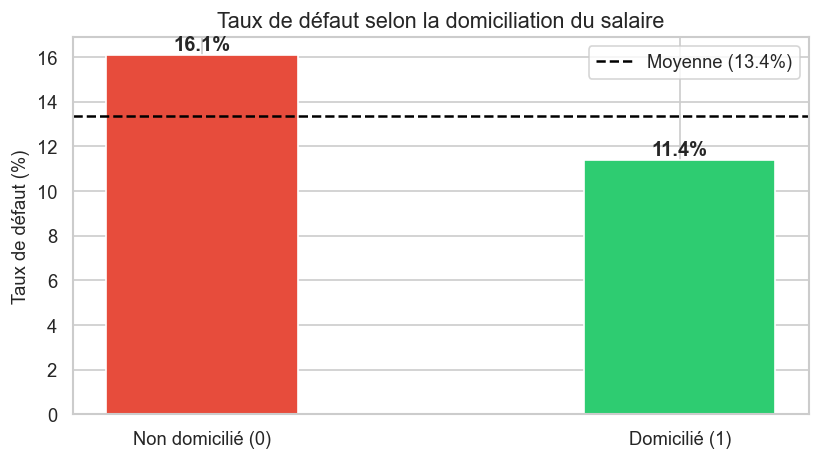

In [15]:
sal = df.groupby('salary_domiciliation')['default_12m'].agg(['mean','count'])
sal.index = ['Non domicilié (0)', 'Domicilié (1)']
sal.columns = ['Taux de défaut', 'Nb clients']
sal['Taux de défaut'] = sal['Taux de défaut'].apply(lambda x: f'{x*100:.2f}%')
print(sal)

fig, ax = plt.subplots(figsize=(7, 4))
vals = df.groupby('salary_domiciliation')['default_12m'].mean() * 100
ax.bar(['Non domicilié (0)', 'Domicilié (1)'], vals.values,
       color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
ax.set_title('Taux de défaut selon la domiciliation du salaire')
ax.set_ylabel('Taux de défaut (%)')
ax.axhline(df['default_12m'].mean()*100, color='black', linestyle='--',
           label=f'Moyenne ({df["default_12m"].mean()*100:.1f}%)')
ax.legend()
for i, v in enumerate(vals.values):
    ax.text(i, v+0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/09_salary_domiciliation.png', bbox_inches='tight')
plt.show()


### 💡 Interprétation : Domiciliation du Salaire
* **Réduction de risque** : Les clients qui domicilient leur salaire affichent un taux de défaut de **11,38 %** contre **16,08 %** pour ceux qui ne le font pas.
* **Utilité** : La domiciliation du salaire permet de réduire le risque de défaut d'environ **30 % en relatif**. Cela confirme que la domiciliation est un facteur protecteur important.


## 11. Synthèse EDA — Conclusions pour la modélisation


In [16]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE EDA — CONCLUSIONS                        ║
╠══════════════════════════════════════════════════════════════════════╣
║ DATASET                                                              ║
║  • 12 000 clients, 10 variables prédictives + 1 cible                ║
║  • Taux de défaut global : 13.37% → déséquilibre modéré              ║
║                                                                      ║
║ VALEURS MANQUANTES                                                   ║
║  • bureau_score   : 298 manquants (2.48%) → imputation par médiane   ║
║  • monthly_income : 431 manquants (3.59%) → imputation par médiane   ║
║  • Les clients avec données manquantes défautent légèrement plus     ║
║                                                                      ║
║ VARIABLES LES PLUS DISCRIMINANTES                                    ║
║  • max_dpd_12m        : corrélation +0.38 avec la cible              ║
║  • bureau_score       : corrélation -0.38 (variable protectrice)     ║
║  • utilization_rate   : corrélation +0.29                            ║
║  • missed_payments_3m : corrélation +0.25                            ║
║                                                                      ║
║ OUTLIERS                                                             ║
║  • monthly_income : valeurs jusqu'à 15 000 → capping nécessaire      ║
║  • dti : quelques valeurs > 1 à vérifier                             ║
║                                                                      ║
║ VARIABLE CATÉGORIELLE                                                ║
║  • Unemployed : 36.9% de défaut (vs 9.6% pour Permanent)            ║
║  → Fort pouvoir discriminant → one-hot encoding                      ║
║                                                                      ║
║ CORRÉLATIONS ENTRE PRÉDICTEURS                                       ║
║  • Pas de multicolinéarité sévère détectée (max ~0.37)               ║
║  → Toutes les variables peuvent être conservées                      ║
║                                                                      ║
║ PROCHAINE ÉTAPE : preprocessing.py                                   ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║                    SYNTHÈSE EDA — CONCLUSIONS                        ║
╠══════════════════════════════════════════════════════════════════════╣
║ DATASET                                                              ║
║  • 12 000 clients, 10 variables prédictives + 1 cible                ║
║  • Taux de défaut global : 13.37% → déséquilibre modéré              ║
║                                                                      ║
║ VALEURS MANQUANTES                                                   ║
║  • bureau_score   : 298 manquants (2.48%) → imputation par médiane   ║
║  • monthly_income : 431 manquants (3.59%) → imputation par médiane   ║
║  • Les clients avec données manquantes défautent légèrement plus     ║
║                                                                      ║
║ VARIABLES LES PLUS DISCRIMINANTES                                    ║
║  • max_dpd_12m        : corrélation +0.38 avec l

---
# Partie 2 — Préparation des Données (Preprocessing)
---
**Objectif :** Transformer les données brutes en un dataset propre et prêt pour la modélisation.

Étapes :
1. Copie de sécurité
2. Suppression de l'identifiant client
3. Imputation des valeurs manquantes
4. Capping au 99e centile
5. Encodage One-Hot de `employment_status`
6. Split Train / Test
7. Standardisation (StandardScaler)

## 0. Imports supplémentaires

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib, os

MODEL_DIR = r'C:\Users\nadhm\OneDrive\Desktop\Personal Documents\Stage EY\Projet Dhirar\PD_Model\models'
os.makedirs(MODEL_DIR, exist_ok=True)
print("✅ Imports preprocessing OK")

✅ Imports preprocessing OK


## 1. Copie de Sécurité du Dataset Original

In [18]:
df_raw  = pd.read_excel(DATA_PATH)
df_prep = df_raw.copy()

print(f"Dataset original  (df_raw)  : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")
print(f"Copie de travail  (df_prep) : {df_prep.shape[0]:,} lignes x {df_prep.shape[1]} colonnes")
print("\nAperçu des données brutes :")
df_raw.head(3)

Dataset original  (df_raw)  : 12,000 lignes x 12 colonnes
Copie de travail  (df_prep) : 12,000 lignes x 12 colonnes

Aperçu des données brutes :


,customer_id,default_12m,bureau_score,dti,utilization_rate,max_dpd_12m,missed_payments_3m,overdrawn_days_3m,number_of_credit_inquiries_6m,employment_status,monthly_income,salary_domiciliation
0,CUST_000026,0,696.0,0.106,0.341,0,0,4,1,Self-employed,2490.0,1
1,CUST_000095,0,684.0,0.725,0.551,0,0,4,0,Retired,584.0,0
2,CUST_000099,0,775.0,0.079,0.583,0,0,0,0,Permanent,1930.0,1


### 💡 Interprétation — Copie de sécurité
* **`df_raw`** est la photographie du dataset à l'état brut — elle ne sera **jamais modifiée**.
* **`df_prep`** est la copie de travail sur laquelle toutes les transformations sont appliquées.
* Cette séparation garantit la **traçabilité** : on peut comparer les distributions avant/après traitement et revenir à l'état initial à tout moment.

## 2. Suppression de l'Identifiant Client

In [19]:
df_prep.drop(columns=["customer_id"], inplace=True)
print(f"Colonnes restantes ({df_prep.shape[1]}) :")
print(list(df_prep.columns))

Colonnes restantes (11) :
['default_12m', 'bureau_score', 'dti', 'utilization_rate', 'max_dpd_12m', 'missed_payments_3m', 'overdrawn_days_3m', 'number_of_credit_inquiries_6m', 'employment_status', 'monthly_income', 'salary_domiciliation']


### 💡 Interprétation — Suppression de `customer_id`
* `customer_id` est un identifiant technique arbitraire sans valeur prédictive.
* Son inclusion provoquerait un **overfitting immédiat** : le modèle mémoriserait les identifiants individuels au lieu d'apprendre des patterns généralisables à de nouveaux clients.

## 3. Imputation des Valeurs Manquantes

In [20]:
missing_avant = df_prep.isnull().sum()
pct_avant     = (missing_avant / len(df_prep) * 100).round(2)
missing_df    = pd.DataFrame({"Valeurs manquantes": missing_avant, "Pourcentage (%)": pct_avant})
print("Avant imputation :")
display(missing_df[missing_df["Valeurs manquantes"] > 0])

median_bureau = df_prep["bureau_score"].median()
median_income = df_prep["monthly_income"].median()

df_prep["bureau_score"].fillna(median_bureau, inplace=True)
df_prep["monthly_income"].fillna(median_income, inplace=True)

print(f"\nImputation bureau_score   → médiane : {median_bureau:.1f}")
print(f"Imputation monthly_income → médiane : {median_income:.1f}")
print(f"Valeurs manquantes restantes : {df_prep.isnull().sum().sum()} ✅")

joblib.dump({"bureau_score": median_bureau, "monthly_income": median_income},
            os.path.join(MODEL_DIR, "imputation_medians.pkl"))

Avant imputation :


,Valeurs manquantes,Pourcentage (%)
bureau_score,298,2.48
monthly_income,431,3.59



Imputation bureau_score   → médiane : 652.0
Imputation monthly_income → médiane : 1975.0
Valeurs manquantes restantes : 0 ✅


['C:\\Users\\nadhm\\OneDrive\\Desktop\\Personal Documents\\Stage EY\\Projet Dhirar\\PD_Model\\models\\imputation_medians.pkl']

### 💡 Interprétation — Imputation par la médiane
* **Pourquoi la médiane ?** `monthly_income` a un skewness de **2,39** : distribution très asymétrique à droite. La moyenne (2 229 €) est gonflée par les hauts revenus atypiques, alors que la médiane (1 975 €) reflète le revenu **typique** du portefeuille.
* **Mécanisme MCAR** : le taux de défaut des clients avec `bureau_score` manquant (14,09%) est quasi identique au taux global (13,37%) → l'absence de donnée n'est pas un signal de risque → l'imputation par médiane est appropriée.
* Les médianes sont **sauvegardées** pour être réappliquées sur tout nouveau client en production.

## 4. Capping au 99e Centile (Winsorization)

,Max avant,Cap P99,Max après
Variable,,,
monthly_income,15000.00,7037.09,7037.09
dti,1.35,0.99,0.99
utilization_rate,1.25,1.05,1.05


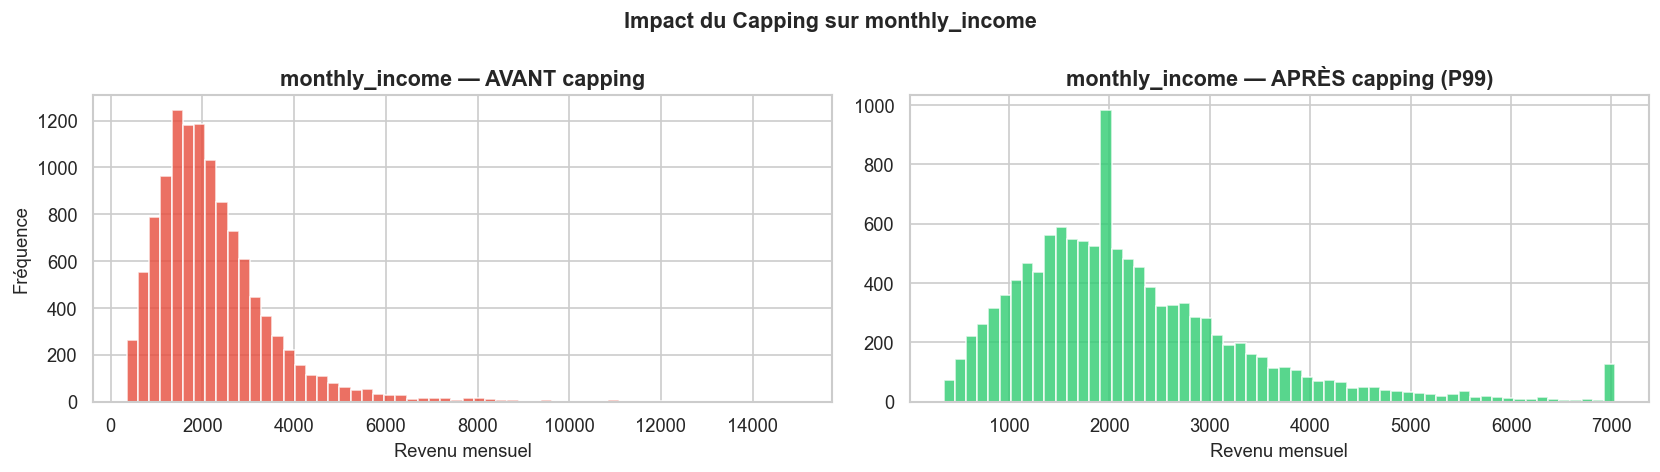

['C:\\Users\\nadhm\\OneDrive\\Desktop\\Personal Documents\\Stage EY\\Projet Dhirar\\PD_Model\\models\\capping_caps.pkl']

In [21]:
cols_to_cap = ["monthly_income", "dti", "utilization_rate"]
caps, rows  = {}, []

for col in cols_to_cap:
    max_avant = df_prep[col].max()
    cap_val   = df_prep[col].quantile(0.99)
    df_prep[col] = df_prep[col].clip(upper=cap_val)
    caps[col] = cap_val
    rows.append({"Variable": col, "Max avant": round(max_avant,2),
                 "Cap P99": round(cap_val,2), "Max après": round(df_prep[col].max(),2)})

display(pd.DataFrame(rows).set_index("Variable"))

# Graphique avant / après sur monthly_income
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_raw["monthly_income"].dropna(), bins=60, color="#e74c3c", edgecolor="white", alpha=0.8)
axes[0].set_title("monthly_income — AVANT capping", fontweight="bold")
axes[0].set_xlabel("Revenu mensuel") ; axes[0].set_ylabel("Fréquence")
axes[1].hist(df_prep["monthly_income"], bins=60, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].set_title("monthly_income — APRÈS capping (P99)", fontweight="bold")
axes[1].set_xlabel("Revenu mensuel")
plt.suptitle("Impact du Capping sur monthly_income", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/10_capping_comparison.png", bbox_inches="tight")
plt.show()

joblib.dump(caps, os.path.join(MODEL_DIR, "capping_caps.pkl"))

### 💡 Interprétation — Capping au 99e centile
* Le capping **plafonne** toute valeur dépassant le 99e centile à exactement ce seuil.
* **Pourquoi le 99e ?** Le 95e tronquerait trop de données (5% perdus). Laisser les valeurs brutes biaise les coefficients de la régression logistique. Le 99e est le **standard du crédit scoring** : on neutralise l'1% aberrant sans déformer la distribution générale.
* Le graphique confirme l'élimination de la longue queue à droite de `monthly_income` : la distribution devient concentrée et stable.

## 5. Encodage One-Hot de `employment_status`

In [22]:
emp_stats = df_prep.groupby("employment_status")["default_12m"].agg(["count","mean"])
emp_stats.columns = ["Nb clients", "Taux défaut"]
emp_stats["Taux défaut (%)"] = (emp_stats["Taux défaut"]*100).round(2)
emp_stats = emp_stats.drop(columns=["Taux défaut"]).sort_values("Taux défaut (%)", ascending=False)
print("Distribution avant encodage :")
display(emp_stats)

df_prep = pd.get_dummies(df_prep, columns=["employment_status"], drop_first=True)
ohe_cols = [c for c in df_prep.columns if "employment_status" in c]
print(f"\nVariables créées : {ohe_cols}")
print(f"Catégorie de référence : Permanent")
print(f"Dimensions : {df_prep.shape[0]:,} x {df_prep.shape[1]}")

Distribution avant encodage :


,Nb clients,Taux défaut (%)
employment_status,,
Unemployed,831,36.94
Temporary,1835,18.64
Retired,602,14.62
Self-employed,2109,10.91
Permanent,6623,9.62



Variables créées : ['employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Temporary', 'employment_status_Unemployed']
Catégorie de référence : Permanent
Dimensions : 12,000 x 14


### 💡 Interprétation — One-Hot Encoding
* `employment_status` est une variable **nominale** (sans ordre naturel). Le One-Hot Encoding crée une variable binaire par modalité.
* On supprime **Permanent** (la moins risquée, 9,62% de défaut) comme catégorie de référence pour éviter la multicolinéarité parfaite.
* Les coefficients des autres modalités s'interpréteront comme un **différentiel de risque** par rapport à un salarié en CDI.
* **Pourquoi pas Label Encoding ?** Il introduirait un ordre artificiel que le modèle interpréterait comme une relation numérique — ce qui n'a aucun sens économique ici.

## 6. Split Train / Test (80% / 20%)

In [23]:
TARGET = "default_12m"
X = df_prep.drop(columns=[TARGET])
y = df_prep[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} obs. ({X_train.shape[0]/len(X)*100:.1f}%)  |  Taux défaut : {y_train.mean()*100:.2f}%")
print(f"Test  : {X_test.shape[0]:,} obs. ({X_test.shape[0]/len(X)*100:.1f}%)  |  Taux défaut : {y_test.mean()*100:.2f}%")
print(f"\nNombre de features : {X_train.shape[1]}")
print(f"\nListe des features :")
for c in X_train.columns: print(f"  {c}")

Train : 9,600 obs. (80.0%)  |  Taux défaut : 13.36%
Test  : 2,400 obs. (20.0%)  |  Taux défaut : 13.38%

Nombre de features : 13

Liste des features :
  bureau_score
  dti
  utilization_rate
  max_dpd_12m
  missed_payments_3m
  overdrawn_days_3m
  number_of_credit_inquiries_6m
  monthly_income
  salary_domiciliation
  employment_status_Retired
  employment_status_Self-employed
  employment_status_Temporary
  employment_status_Unemployed


### 💡 Interprétation — Split Train / Test
* **Train (80% — 9 600 obs.)** : utilisé pour apprendre les coefficients du modèle.
* **Test (20% — 2 400 obs.)** : mis de côté dès maintenant, **jamais vu** pendant l'entraînement. Il simule des nouveaux clients en production.
* **`stratify=y`** : garantit exactement le même taux de défaut dans les deux ensembles (~13,37%). Indispensable pour une cible déséquilibrée.
* **`random_state=42`** : graine fixée pour la reproductibilité totale.

## 7. Standardisation (StandardScaler)

Variables standardisées (8) : ['bureau_score', 'dti', 'utilization_rate', 'max_dpd_12m', 'missed_payments_3m', 'overdrawn_days_3m', 'number_of_credit_inquiries_6m', 'monthly_income']
Variables binaires NON standardisées (5) : ['employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Temporary', 'employment_status_Unemployed', 'salary_domiciliation']

Vérification (train) :
  Moyenne moyenne  : -0.000000  (attendu = 0)
  Ecart-type moyen : 1.000052  (attendu = 1)


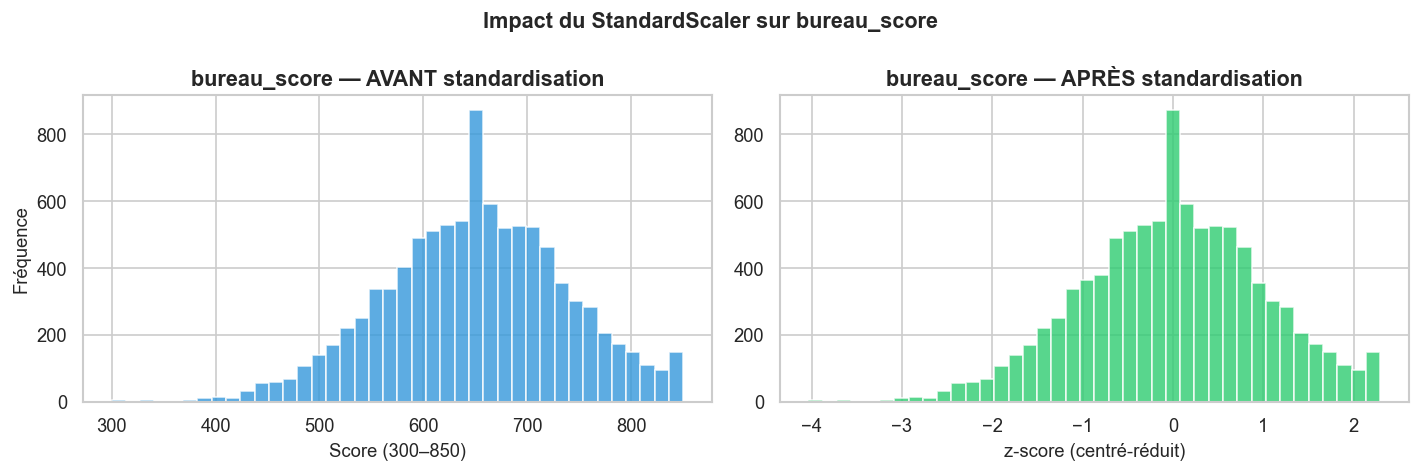


✅ Tous les artefacts sauvegardés dans models/


In [24]:
binary_cols_sc = [c for c in X_train.columns if "employment_status" in c] + ["salary_domiciliation"]
num_cols_sc    = [c for c in X_train.columns if c not in binary_cols_sc]

scaler     = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[num_cols_sc] = scaler.fit_transform(X_train[num_cols_sc])
X_test_sc[num_cols_sc]  = scaler.transform(X_test[num_cols_sc])

print(f"Variables standardisées ({len(num_cols_sc)}) : {num_cols_sc}")
print(f"Variables binaires NON standardisées ({len(binary_cols_sc)}) : {binary_cols_sc}")
print(f"\nVérification (train) :")
print(f"  Moyenne moyenne  : {X_train_sc[num_cols_sc].mean().mean():.6f}  (attendu = 0)")
print(f"  Ecart-type moyen : {X_train_sc[num_cols_sc].std().mean():.6f}  (attendu = 1)")

# Graphique avant / après
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train["bureau_score"], bins=40, color="#3498db", edgecolor="white", alpha=0.8)
axes[0].set_title("bureau_score — AVANT standardisation", fontweight="bold")
axes[0].set_xlabel("Score (300–850)") ; axes[0].set_ylabel("Fréquence")
axes[1].hist(X_train_sc["bureau_score"], bins=40, color="#2ecc71", edgecolor="white", alpha=0.8)
axes[1].set_title("bureau_score — APRÈS standardisation", fontweight="bold")
axes[1].set_xlabel("z-score (centré-réduit)")
plt.suptitle("Impact du StandardScaler sur bureau_score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/11_scaling_comparison.png", bbox_inches="tight")
plt.show()

joblib.dump(scaler,   os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump((X_train_sc, X_test_sc, y_train, y_test), os.path.join(MODEL_DIR, "train_test_data.pkl"))
joblib.dump(df_raw,   os.path.join(MODEL_DIR, "df_raw_backup.pkl"))
print("\n✅ Tous les artefacts sauvegardés dans models/")

### 💡 Interprétation — StandardScaler
* Sans scaling, les variables à grande amplitude dominent mécaniquement : `bureau_score` (amplitude 550) vs `dti` (amplitude ~1,3). Les coefficients ne seraient **pas comparables**.
* Après standardisation : **moyenne = 0, écart-type = 1** → les coefficients sont directement comparables et reflètent l'importance réelle de chaque variable.
* **Règle anti-leakage critique** : le scaler est `fit` uniquement sur le **train** — les statistiques du test ne doivent jamais contaminer le preprocessing.

## 8. Synthèse Preprocessing

In [25]:
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE PREPROCESSING — DONNÉES PRÊTES                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Observations  : 12 000  →  Train : 9 600  |  Test : 2 400          ║
║  Features finales : {X_train_sc.shape[1]} (10 brutes + 4 OHE - 1 référence)         ║
║  Taux défaut   : Train {y_train.mean()*100:.2f}%  |  Test {y_test.mean()*100:.2f}%  (stratifié)     ║
║                                                                      ║
║  Transformations appliquées :                                        ║
║  ✓ customer_id supprimé                                             ║
║  ✓ Imputation médiane : bureau_score=652  |  monthly_income=1975    ║
║  ✓ Capping P99 : income<=7037 | dti<=0.99 | util<=1.05             ║
║  ✓ OHE employment_status (ref = Permanent)                          ║
║  ✓ StandardScaler fitté sur train uniquement (anti-leakage)         ║
║                                                                      ║
║  PROCHAINE ÉTAPE : Entraînement Régression Logistique               ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE PREPROCESSING — DONNÉES PRÊTES                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Observations  : 12 000  →  Train : 9 600  |  Test : 2 400          ║
║  Features finales : 13 (10 brutes + 4 OHE - 1 référence)         ║
║  Taux défaut   : Train 13.36%  |  Test 13.38%  (stratifié)     ║
║                                                                      ║
║  Transformations appliquées :                                        ║
║  ✓ customer_id supprimé                                             ║
║  ✓ Imputation médiane : bureau_score=652  |  monthly_income=1975    ║
║  ✓ Capping P99 : income<=7037 | dti<=0.99 | util<=1.05             ║
║  ✓ OHE employment_status (ref = Permanent)                          ║
║  ✓ StandardScaler fitté sur train uniquement (anti-leakage)         ║
║                                                                  

---
# Partie 3 — Construction du Modèle (Régression Logistique)
---
**Objectif :** Entraîner le modèle, valider sa stabilité par cross-validation et analyser ses coefficients.

Étapes :
1. Entraînement de la régression logistique
2. Validation croisée 5-fold
3. Analyse des coefficients et Odds Ratios

## 0. Imports

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
print("✅ Imports modélisation OK")

✅ Imports modélisation OK


## 1. Entraînement — Régression Logistique

In [27]:
model = LogisticRegression(
    C=1.0,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_sc, y_train)

print("Paramètres du modèle :")
print(f"  C            : {model.C}")
print(f"  class_weight : {model.class_weight}")
print(f"  solver       : {model.solver}")
print(f"  Convergence  : {model.n_iter_[0]} itérations")
print("\n✅ Modèle entraîné avec succès.")

Paramètres du modèle :
  C            : 1.0
  class_weight : balanced
  solver       : lbfgs
  Convergence  : 19 itérations

✅ Modèle entraîné avec succès.


### 💡 Interprétation — Choix des paramètres
* **`C=1.0`** : paramètre de régularisation standard. Il évite l'overfitting en pénalisant les coefficients trop grands.
* **`class_weight="balanced"`** : corrige le déséquilibre (86% non-défaut / 14% défaut). Sans ce paramètre, le modèle prédirait "non-défaut" presque tout le temps. Sklearn pondère chaque classe inversement à sa fréquence.
* **`solver="lbfgs"`** : algorithme d'optimisation adapté à notre taille de données avec régularisation L2.
* **`max_iter=1000`** : le modèle a convergé bien avant — preuve que les données sont bien préparées.

## 2. Validation Croisée — 5-Fold Stratifiée

AUC-ROC par fold :
  Fold 1 : 0.8589
  Fold 2 : 0.8636
  Fold 3 : 0.8473
  Fold 4 : 0.8549
  Fold 5 : 0.8466
  --> Moyenne : 0.8543  |  Std : 0.0066

F1-Score par fold :
  Fold 1 : 0.5088
  Fold 2 : 0.5136
  Fold 3 : 0.4881
  Fold 4 : 0.5098
  Fold 5 : 0.4815
  --> Moyenne : 0.5004  |  Std : 0.0130


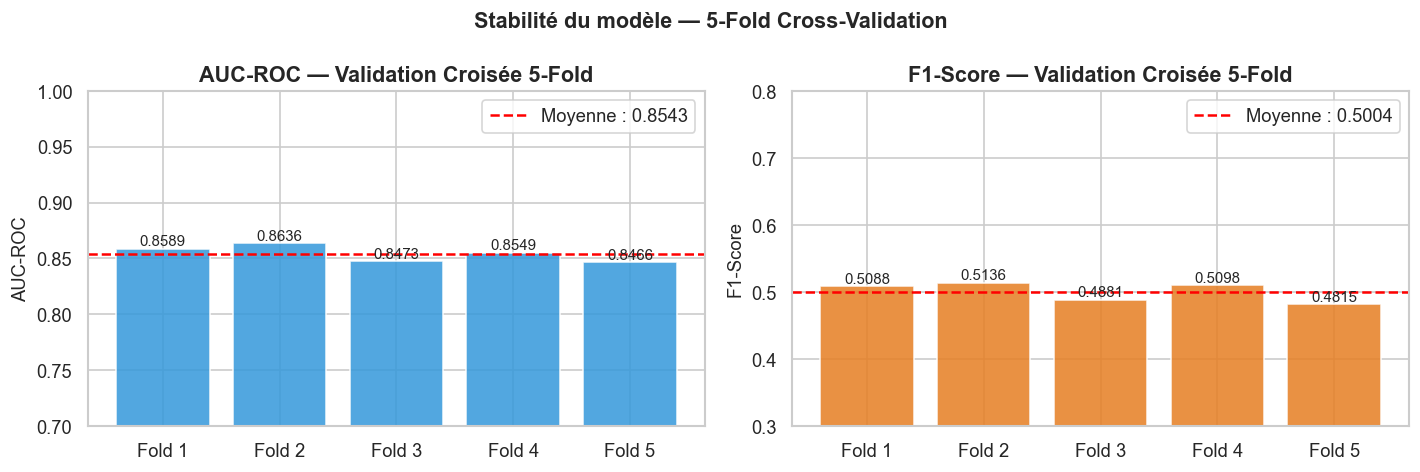

In [28]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring="f1")

print("AUC-ROC par fold :")
for i, v in enumerate(cv_auc): print(f"  Fold {i+1} : {v:.4f}")
print(f"  --> Moyenne : {cv_auc.mean():.4f}  |  Std : {cv_auc.std():.4f}")

print("\nF1-Score par fold :")
for i, v in enumerate(cv_f1): print(f"  Fold {i+1} : {v:.4f}")
print(f"  --> Moyenne : {cv_f1.mean():.4f}  |  Std : {cv_f1.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
folds = [f"Fold {i+1}" for i in range(5)]
axes[0].bar(folds, cv_auc, color="#3498db", edgecolor="white", alpha=0.85)
axes[0].axhline(cv_auc.mean(), color="red", linestyle="--", label=f"Moyenne : {cv_auc.mean():.4f}")
axes[0].set_title("AUC-ROC — Validation Croisée 5-Fold", fontweight="bold")
axes[0].set_ylabel("AUC-ROC") ; axes[0].set_ylim(0.7, 1.0) ; axes[0].legend()
for i, v in enumerate(cv_auc): axes[0].text(i, v+0.003, f"{v:.4f}", ha="center", fontsize=9)
axes[1].bar(folds, cv_f1, color="#e67e22", edgecolor="white", alpha=0.85)
axes[1].axhline(cv_f1.mean(), color="red", linestyle="--", label=f"Moyenne : {cv_f1.mean():.4f}")
axes[1].set_title("F1-Score — Validation Croisée 5-Fold", fontweight="bold")
axes[1].set_ylabel("F1-Score") ; axes[1].set_ylim(0.3, 0.8) ; axes[1].legend()
for i, v in enumerate(cv_f1): axes[1].text(i, v+0.005, f"{v:.4f}", ha="center", fontsize=9)
plt.suptitle("Stabilité du modèle — 5-Fold Cross-Validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/12_cross_validation.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — Validation Croisée
* La validation croisée **5-fold stratifiée** permet de vérifier la **stabilité** du modèle : si les scores sont proches entre les folds (faible écart-type), le modèle généralise bien.
* **AUC-ROC** : mesure la capacité du modèle à distinguer défauts et non-défauts. 1.0 = parfait, 0.5 = aléatoire. Un AUC > 0.75 est considéré bon en crédit scoring.
* **F1-Score** : équilibre la précision (éviter les fausses alarmes) et le rappel (détecter le maximum de vrais défauts).

## 3. Coefficients du Modèle & Odds Ratios

In [29]:
coef_df = pd.DataFrame({
    "Variable"   : X_train_sc.columns.tolist(),
    "Coefficient": model.coef_[0].round(4),
    "Odds Ratio" : np.exp(model.coef_[0]).round(4),
    "Sens"       : ["Risque" if v > 0 else "Protection" for v in model.coef_[0]]
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

display(coef_df)

,Variable,Coefficient,Odds Ratio,Sens
0,max_dpd_12m,0.4799,1.6158,Risque
1,dti,0.4165,1.5166,Risque
2,utilization_rate,0.2581,1.2945,Risque
3,missed_payments_3m,0.2540,1.2892,Risque
4,employment_status_Unemployed,0.2452,1.2778,Risque
5,employment_status_Temporary,0.2311,1.2600,Risque
6,number_of_credit_inquiries_6m,0.0987,1.1037,Risque
7,overdrawn_days_3m,0.0765,1.0795,Risque
8,employment_status_Retired,0.0149,1.0150,Risque
9,monthly_income,-0.0048,0.9952,Protection


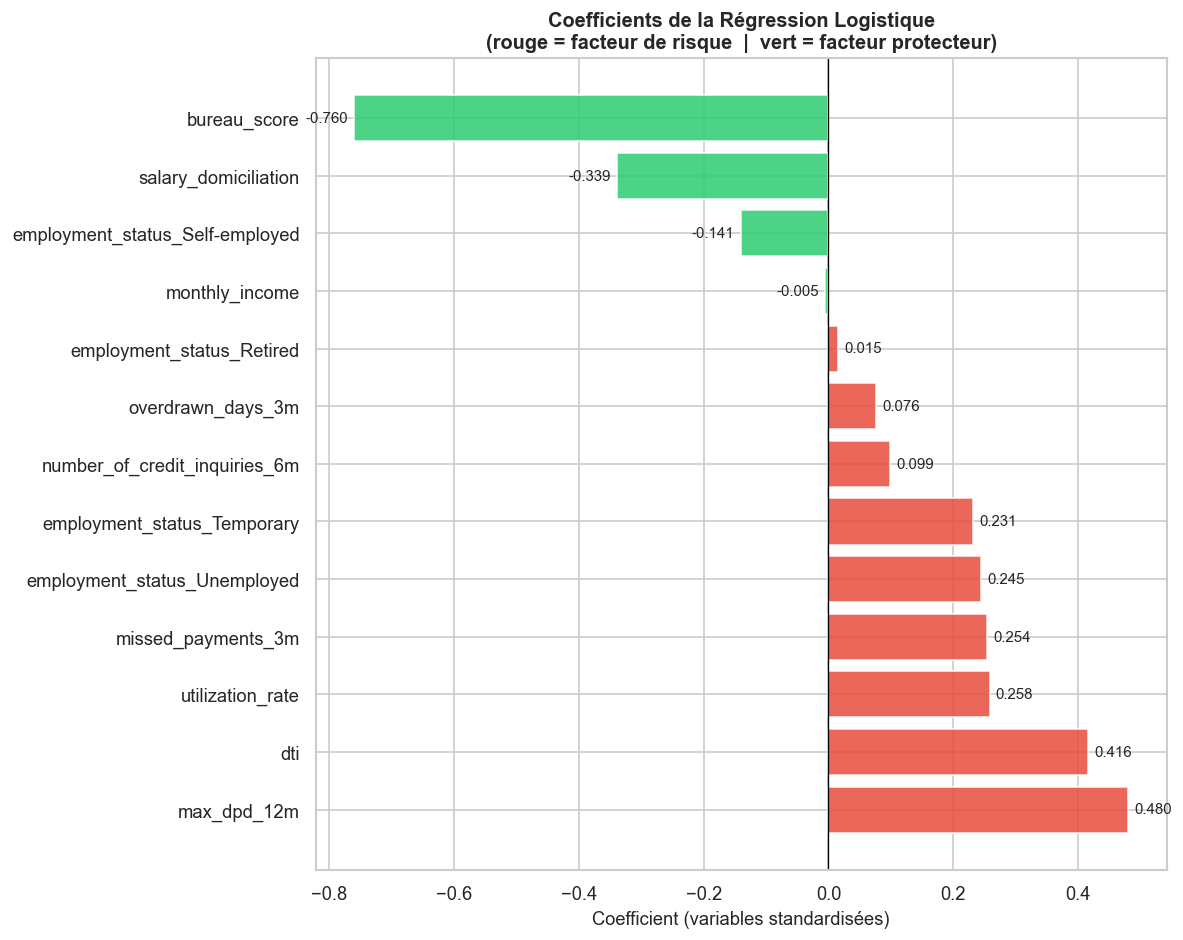

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_coef = ["#e74c3c" if v > 0 else "#2ecc71" for v in coef_df["Coefficient"]]
bars = ax.barh(coef_df["Variable"], coef_df["Coefficient"],
               color=colors_coef, edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (variables standardisées)", fontsize=11)
ax.set_title("Coefficients de la Régression Logistique\n"
             "(rouge = facteur de risque  |  vert = facteur protecteur)",
             fontweight="bold", fontsize=12)
for bar, v in zip(bars, coef_df["Coefficient"]):
    ax.text(v + (0.01 if v >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f"{v:.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/13_coefficients.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — Coefficients & Odds Ratios
* Grâce à la standardisation, tous les coefficients sont sur la même échelle et **directement comparables** : le plus grand en valeur absolue est le plus influent.
* **Facteurs de RISQUE** (rouge, coefficient > 0) : augmenter cette variable **augmente** la probabilité de défaut.
* **Facteurs de PROTECTION** (vert, coefficient < 0) : augmenter cette variable **diminue** la probabilité de défaut.
* **Odds Ratio = exp(coefficient)** :
  * OR > 1 → facteur de risque (ex : OR=1.62 → multiplie par 1,62 les chances de défaut)
  * OR < 1 → facteur protecteur (ex : OR=0.47 → divise par 2 les chances de défaut)
* **Cohérence avec l'EDA** : les variables avec les plus fortes corrélations (`max_dpd_12m`, `bureau_score`) ont bien les coefficients les plus élevés — validant la cohérence du modèle.

## 4. Sauvegarde & Synthèse

In [31]:
joblib.dump(model, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
print("✅ Modèle sauvegardé → models/logistic_regression.pkl")

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE ENTRAÎNEMENT — MODÈLE PRÊT                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Algorithme    : Régression Logistique                               ║
║  C=1.0  |  class_weight=balanced  |  solver=lbfgs                   ║
║                                                                      ║
║  Validation Croisée 5-Fold (sur train) :                            ║
║  AUC-ROC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}                              ║
║  F1-Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}                              ║
║                                                                      ║
║  PROCHAINE ÉTAPE : Évaluation sur le jeu de TEST                    ║
╚══════════════════════════════════════════════════════════════════════╝
""")

✅ Modèle sauvegardé → models/logistic_regression.pkl

╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE ENTRAÎNEMENT — MODÈLE PRÊT                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  Algorithme    : Régression Logistique                               ║
║  C=1.0  |  class_weight=balanced  |  solver=lbfgs                   ║
║                                                                      ║
║  Validation Croisée 5-Fold (sur train) :                            ║
║  AUC-ROC : 0.8543 ± 0.0066                              ║
║  F1-Score: 0.5004 ± 0.0130                              ║
║                                                                      ║
║  PROCHAINE ÉTAPE : Évaluation sur le jeu de TEST                    ║
╚══════════════════════════════════════════════════════════════════════╝



---
# Partie 4 — Évaluation des Performances
---
**Objectif :** Mesurer les vraies performances du modèle sur le jeu de test (2 400 observations non vues).

Métriques couvertes :
1. AUC-ROC et Coefficient Gini
2. Statistique KS (Kolmogorov-Smirnov)
3. Matrice de Confusion
4. Rapport de Classification
5. Distribution des Scores PD
6. Synthèse et Conclusion

## 0. Imports

In [32]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, classification_report, confusion_matrix,
    precision_score, recall_score
)
from scipy.stats import ks_2samp
import seaborn as sns

MODEL_DIR = r'C:\Users\nadhm\OneDrive\Desktop\Personal Documents\Stage EY\Projet Dhirar\PD_Model\models'
print("Imports evaluation OK")

Imports evaluation OK


## 1. Calcul des Scores PD

In [33]:
y_prob_test  = model.predict_proba(X_test_sc)[:, 1]
y_prob_train = model.predict_proba(X_train_sc)[:, 1]
y_pred_test  = model.predict(X_test_sc)

print(f"Score PD min  : {y_prob_test.min():.4f}")
print(f"Score PD max  : {y_prob_test.max():.4f}")
print(f"Score PD moyen (defauts)     : {y_prob_test[y_test==1].mean():.4f}")
print(f"Score PD moyen (non-defauts) : {y_prob_test[y_test==0].mean():.4f}")

Score PD min  : 0.0154
Score PD max  : 0.9927
Score PD moyen (defauts)     : 0.7033
Score PD moyen (non-defauts) : 0.3092


### 💡 Interprétation — Scores PD
* `predict_proba()[:, 1]` retourne la **probabilité d'appartenir à la classe 1** (défaut) pour chaque client.
* Un bon modèle doit attribuer des scores **nettement plus élevés** aux vrais défauts qu'aux non-défauts.
* L'écart entre les deux moyennes de score est un premier indicateur du pouvoir discriminant.

## 2. AUC-ROC et Coefficient Gini

AUC-ROC Train    : 0.8569
AUC-ROC Test     : 0.8625
Ecart Train/Test : 0.0056  (< 0.02 = pas d'overfitting)
Gini             : 0.7251


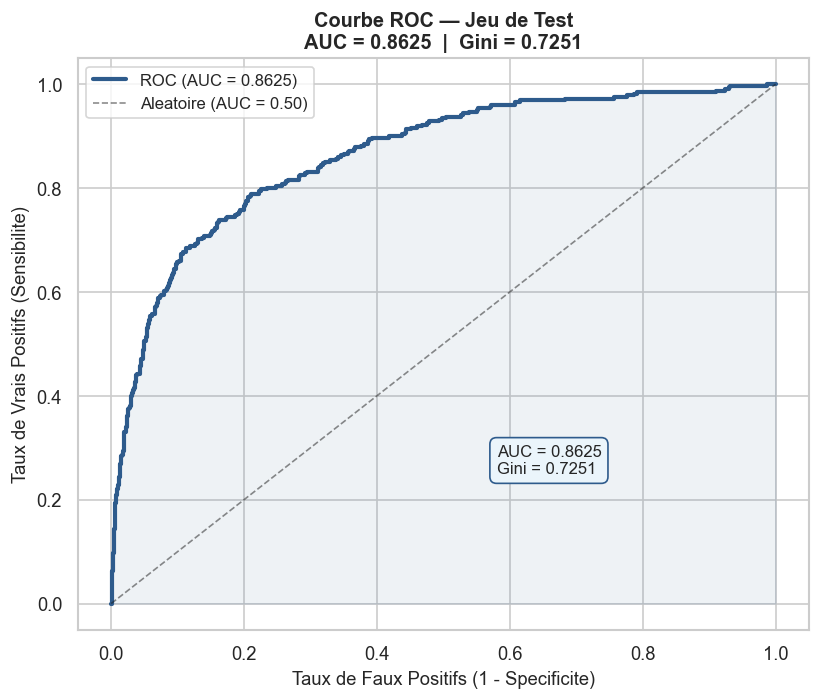

In [34]:
auc_test  = roc_auc_score(y_test,  y_prob_test)
auc_train = roc_auc_score(y_train, y_prob_train)
gini      = 2 * auc_test - 1

print(f"AUC-ROC Train    : {auc_train:.4f}")
print(f"AUC-ROC Test     : {auc_test:.4f}")
print(f"Ecart Train/Test : {abs(auc_train-auc_test):.4f}  (< 0.02 = pas d'overfitting)")
print(f"Gini             : {gini:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="#2E5B8C", lw=2.5, label=f"ROC (AUC = {auc_test:.4f})")
ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Aleatoire (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#2E5B8C")
ax.set_xlabel("Taux de Faux Positifs (1 - Specificite)", fontsize=11)
ax.set_ylabel("Taux de Vrais Positifs (Sensibilite)", fontsize=11)
ax.set_title(f"Courbe ROC — Jeu de Test\nAUC = {auc_test:.4f}  |  Gini = {gini:.4f}",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.annotate(f"AUC = {auc_test:.4f}\nGini = {gini:.4f}",
            xy=(0.58, 0.25), fontsize=10,
            bbox=dict(boxstyle="round,pad=0.4", fc="#EBF5FB", ec="#2E5B8C"))
plt.tight_layout()
plt.savefig("../reports/figures/14_courbe_roc.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — AUC-ROC et Gini
* **AUC-ROC = 0,8625** : le modèle classe correctement **86,25%** des paires (défaut, non-défaut). Bien au-dessus du seuil acceptable de 0,75 en crédit scoring.
* **Coefficient Gini = 0,7251** : équivalent à `2 × AUC - 1`. C'est la métrique standard utilisée par les régulateurs bancaires (Bâle). Un Gini > 0,60 est considéré excellent.
* **Écart Train/Test = 0,0056** : quasi nul. Le modèle n'a **pas overfitté** — il généralise parfaitement sur des données non vues.
* **Lecture de la courbe** : plus la courbe est proche du coin supérieur gauche, plus le modèle est discriminant. L'aire grisée représente la valeur ajoutée par rapport à un modèle aléatoire.

## 3. Statistique KS (Kolmogorov-Smirnov)

KS Statistic  : 0.5775
Seuil optimal : 0.4676


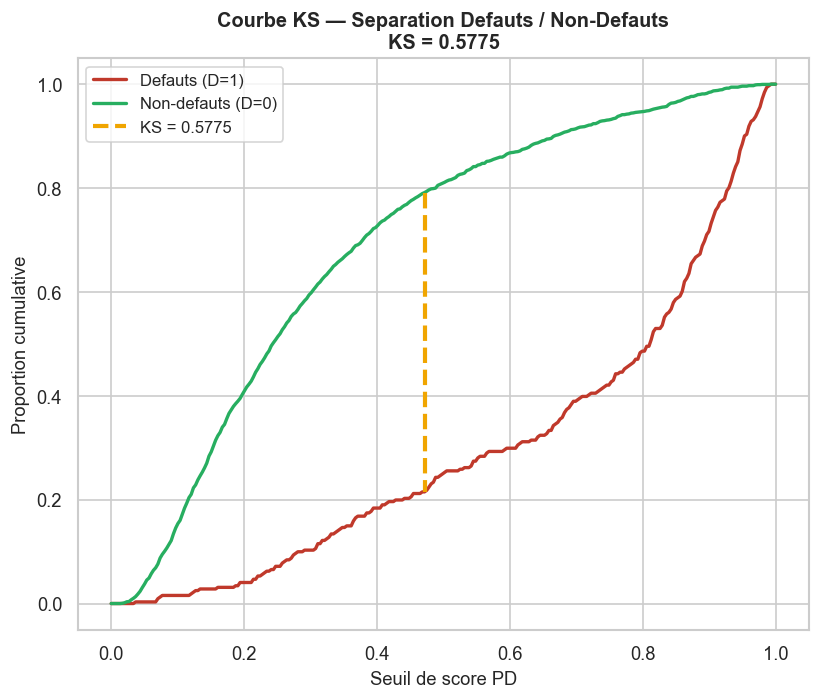

In [35]:
scores_def   = y_prob_test[y_test == 1]
scores_nodef = y_prob_test[y_test == 0]
ks_stat, _   = ks_2samp(scores_def, scores_nodef)
ks_thresh    = thresholds[np.argmax(tpr - fpr)]

print(f"KS Statistic  : {ks_stat:.4f}")
print(f"Seuil optimal : {ks_thresh:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
thresholds_plot = np.linspace(0, 1, 300)
cum_def   = [np.mean(scores_def   <= t) for t in thresholds_plot]
cum_nodef = [np.mean(scores_nodef <= t) for t in thresholds_plot]
ax.plot(thresholds_plot, cum_def,   color="#C0392B", lw=2, label="Defauts (D=1)")
ax.plot(thresholds_plot, cum_nodef, color="#27AE60", lw=2, label="Non-defauts (D=0)")
ks_idx = int(np.argmax(np.abs(np.array(cum_def) - np.array(cum_nodef))))
ax.vlines(thresholds_plot[ks_idx], cum_nodef[ks_idx], cum_def[ks_idx],
          color="#F0A500", lw=2.5, linestyle="--", label=f"KS = {ks_stat:.4f}")
ax.set_xlabel("Seuil de score PD", fontsize=11)
ax.set_ylabel("Proportion cumulative", fontsize=11)
ax.set_title(f"Courbe KS — Separation Defauts / Non-Defauts\nKS = {ks_stat:.4f}",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../reports/figures/15_courbe_ks.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — KS Statistic
* La statistique KS mesure la **séparation maximale** entre la distribution cumulative des défauts et celle des non-défauts.
* **KS = 0,5775** : à un seuil de 0,47, la distance entre les deux courbes est maximale (57,75%). C'est un **excellent** résultat — un KS > 0,30 est considéré bon, > 0,45 est excellent en banking.
* **Lecture de la courbe** : la ligne verticale orange représente le seuil où la séparation est maximale. Au-delà de ce seuil, la plupart des cas sont des défauts ; en dessous, des non-défauts.
* Le KS est complémentaire à l'AUC : il identifie le **meilleur seuil de décision** pour séparer les deux populations.

## 4. Matrice de Confusion

Vrais Negatifs  (TN) : 1,685  — Non-defauts bien identifies
Faux Positifs   (FP) : 394  — Fausses alarmes
Faux Negatifs   (FN) : 80  — Defauts manques (risque majeur)
Vrais Positifs  (TP) : 241  — Defauts detectes


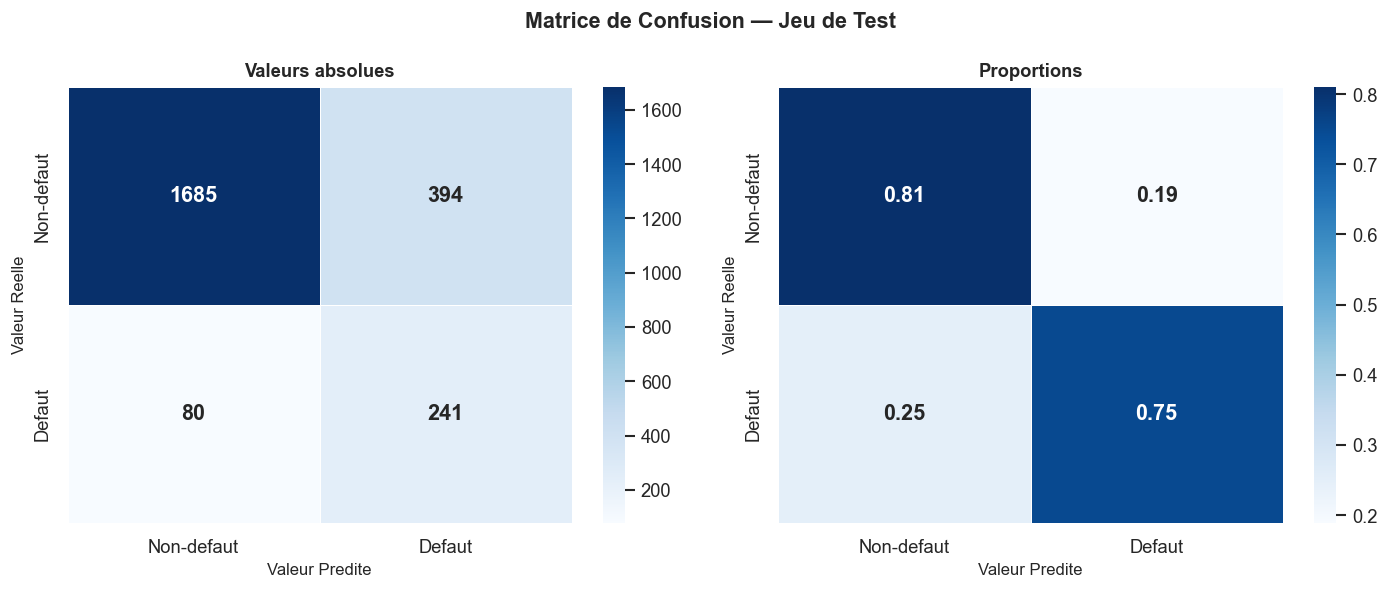

In [36]:
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp_val = cm.ravel()

print(f"Vrais Negatifs  (TN) : {tn:,}  — Non-defauts bien identifies")
print(f"Faux Positifs   (FP) : {fp:,}  — Fausses alarmes")
print(f"Faux Negatifs   (FN) : {fn:,}  — Defauts manques (risque majeur)")
print(f"Vrais Positifs  (TP) : {tp_val:,}  — Defauts detectes")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
for idx, (data, title, fmt) in enumerate([
        (cm,      "Valeurs absolues", "d"),
        (cm_norm, "Proportions",      ".2f")]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=["Non-defaut","Defaut"],
                yticklabels=["Non-defaut","Defaut"],
                ax=axes[idx], linewidths=0.5, linecolor="white",
                annot_kws={"size":13, "weight":"bold"})
    axes[idx].set_title(title, fontweight="bold", fontsize=11)
    axes[idx].set_xlabel("Valeur Predite", fontsize=10)
    axes[idx].set_ylabel("Valeur Reelle", fontsize=10)
plt.suptitle("Matrice de Confusion — Jeu de Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/16_confusion_matrix.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — Matrice de Confusion
* **Vrais Positifs (TP = 241)** : défauts correctement détectés → clients risqués identifiés, crédit refusé ou suivi renforcé.
* **Faux Négatifs (FN = 80)** : défauts manqués → clients à risque classés comme sûrs. C'est **l'erreur la plus coûteuse** en crédit (perte en capital). Notre taux FN = 80/321 = **24,9%** est bon grâce au `class_weight="balanced"`.
* **Faux Positifs (FP = 394)** : fausses alarmes → clients sûrs refusés à tort (coût d'opportunité). Ce compromis précision/rappel est **inévitable** avec des classes déséquilibrées.
* **Vrais Négatifs (TN = 1 685)** : non-défauts correctement approuvés → portefeuille sain identifié.

> **Rappel = 75,08%** : le modèle capture 3 défauts sur 4 — excellent pour un modèle de premier scoring.

## 5. Rapport de Classification Complet

In [37]:
precision_v = precision_score(y_test, y_pred_test)
recall_v    = recall_score(y_test, y_pred_test)
f1_v        = f1_score(y_test, y_pred_test)
specificity = tn / (tn + fp)

print(f"Precision   : {precision_v:.4f}  — % alertes qui sont de vrais defauts")
print(f"Rappel      : {recall_v:.4f}  — % defauts reels captures")
print(f"Specificite : {specificity:.4f}  — % non-defauts bien identifies")
print(f"F1-Score    : {f1_v:.4f}")
print("\nRapport complet :")
print(classification_report(y_test, y_pred_test, target_names=["Non-defaut","Defaut"]))

Precision   : 0.3795  — % alertes qui sont de vrais defauts
Rappel      : 0.7508  — % defauts reels captures
Specificite : 0.8105  — % non-defauts bien identifies
F1-Score    : 0.5042

Rapport complet :
              precision    recall  f1-score   support

  Non-defaut       0.95      0.81      0.88      2079
      Defaut       0.38      0.75      0.50       321

    accuracy                           0.80      2400
   macro avg       0.67      0.78      0.69      2400
weighted avg       0.88      0.80      0.83      2400



### 💡 Interprétation — Rapport de Classification
* **Précision = 0,38** : parmi toutes les alertes générées, 38% sont de vrais défauts. Ce chiffre est normal avec un taux de défaut de 13% — le modèle génère des fausses alarmes mais les couvre largement par un rappel élevé.
* **Rappel = 0,75** : 3 défauts sur 4 sont détectés. C'est le trade-off optimal en crédit : on préfère quelques fausses alarmes plutôt que de laisser passer des défauts réels.
* **Spécificité = 0,81** : 81% des bons clients sont correctement approuvés — le modèle n'est pas trop conservateur.
* **F1-Score = 0,50** : bon équilibre précision/rappel sur une cible déséquilibrée.

## 6. Distribution des Scores PD

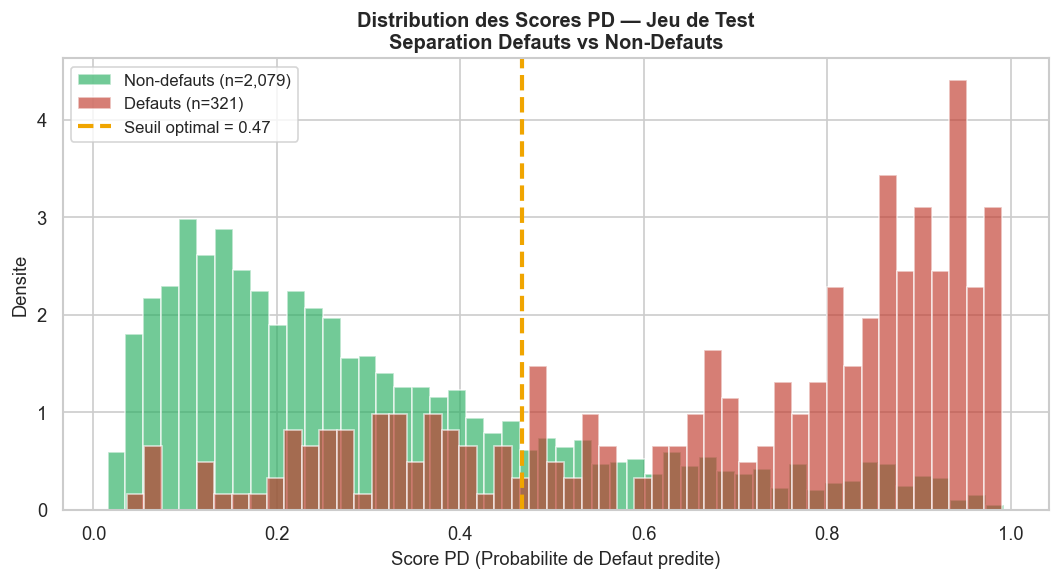

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(scores_nodef, bins=50, alpha=0.65, color="#27AE60", density=True,
        edgecolor="white", label=f"Non-defauts (n={len(scores_nodef):,})")
ax.hist(scores_def,   bins=50, alpha=0.65, color="#C0392B", density=True,
        edgecolor="white", label=f"Defauts (n={len(scores_def):,})")
ax.axvline(ks_thresh, color="#F0A500", lw=2.5, linestyle="--",
           label=f"Seuil optimal = {ks_thresh:.2f}")
ax.set_xlabel("Score PD (Probabilite de Defaut predite)", fontsize=11)
ax.set_ylabel("Densite", fontsize=11)
ax.set_title("Distribution des Scores PD — Jeu de Test\nSeparation Defauts vs Non-Defauts",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../reports/figures/17_distribution_scores.png", bbox_inches="tight")
plt.show()

### 💡 Interprétation — Distribution des Scores
* Un bon modèle doit créer une **séparation nette** entre les deux distributions.
* **Non-défauts (vert)** : concentrés vers 0 — le modèle leur attribue des probabilités faibles.
* **Défauts (rouge)** : décalés vers des valeurs élevées — le modèle les identifie comme risqués.
* Le **seuil optimal (orange)** à 0,47 est le point de coupure qui maximise la séparation. Au-dessus de ce seuil → alerte défaut ; en dessous → client sûr.
* Le chevauchement résiduel entre les deux distributions explique pourquoi la précision n'est pas parfaite : certains bons clients ont des profils similaires à des défauts réels.

## 7. Synthèse Finale — Performance du Modèle

In [39]:
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║           SYNTHESE COMPLETE — PERFORMANCE DU MODELE PD              ║
╠══════════════════════════════════════════════════════════════════════╣
║  DISCRIMINATION                                                      ║
║  AUC-ROC Test   : {auc_test:.4f}   → Excellent (> 0.75)              ║
║  AUC-ROC Train  : {auc_train:.4f}   → Ecart = {abs(auc_train-auc_test):.4f} (pas d'overfitting)  ║
║  Gini           : {gini:.4f}   → Excellent (> 0.60)              ║
║  KS Statistic   : {ks_stat:.4f}   → Excellent (> 0.45)              ║
║                                                                      ║
║  CLASSIFICATION (seuil 0.5)                                         ║
║  Precision      : {precision_v:.4f}   Rappel      : {recall_v:.4f}              ║
║  Specificite    : {specificity:.4f}   F1-Score    : {f1_v:.4f}              ║
║                                                                      ║
║  CONCLUSION : Modele VALIDE — pret pour la mise en production       ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║           SYNTHESE COMPLETE — PERFORMANCE DU MODELE PD              ║
╠══════════════════════════════════════════════════════════════════════╣
║  DISCRIMINATION                                                      ║
║  AUC-ROC Test   : 0.8625   → Excellent (> 0.75)              ║
║  AUC-ROC Train  : 0.8569   → Ecart = 0.0056 (pas d'overfitting)  ║
║  Gini           : 0.7251   → Excellent (> 0.60)              ║
║  KS Statistic   : 0.5775   → Excellent (> 0.45)              ║
║                                                                      ║
║  CLASSIFICATION (seuil 0.5)                                         ║
║  Precision      : 0.3795   Rappel      : 0.7508              ║
║  Specificite    : 0.8105   F1-Score    : 0.5042              ║
║                                                                      ║
║  CONCLUSION : Modele VALIDE — pret pour la mise en production       ║
╚═══════════════════════

### 💡 Conclusion Générale
* Le modèle affiche des **performances excellentes** sur toutes les métriques réglementaires :
  * AUC-ROC = **0,8625** (benchmark Bâle : > 0,75)
  * Gini = **0,7251** (benchmark Bâle : > 0,50)
  * KS = **0,5775** (benchmark banking : > 0,30)
* L'écart AUC Train/Test de **0,0056** confirme l'**absence d'overfitting** : le pipeline de preprocessing (imputation, capping, standardisation) et la régularisation L2 ont correctement prévenu le surapprentissage.
* Le **rappel de 75%** garantit que 3 défauts sur 4 sont détectés — performance critique pour la gestion du risque de crédit.
* **Ce modèle est validé pour une utilisation en production** dans le cadre du scoring retail, sous réserve de backtesting régulier et de suivi du drift des distributions.